# Notebook 5 — Benchmarks, metricas y analisis final

N5 cierra el pipeline completo: compara la estrategia de momentum frente al S&P 500 (SPY), mide retorno y riesgo con las metricas obligatorias del enunciado, diagnostica el impacto operativo de fricciones reales (comisiones, no-fills, proxy exits), y cuantifica la robustez estadistica con 25 millones de carteras aleatorias via Monte Carlo directo.

La pregunta central que N5 responde es: **¿aporta valor la estrategia despues de costes y restricciones reales, o podria obtenerse un resultado equivalente eligiendo activos al azar?** La respuesta se apoya en evidencia numerica, no en intuicion.

**Artefactos de entrada (producidos por N1-N4):**

| Fuente | Artefacto | Proposito |
|---|---|---|
| N1 | `n1_runtime_params.csv`, `n1_benchmark_provenance.csv` | Parametros y benchmark |
| N2 | `n2_signals_input.parquet` | Universo elegible para Monte Carlo |
| N4 | `n4_portfolio_daily.csv`, `n4_orders_log.csv` | Equity y ordenes ejecutadas |
| N4 | `n4_cost_summary.csv`, `n4_rebalance_summary.csv`, `n4_checks.csv` | Costes y controles |

---

## 1. Configuracion y funciones de medida

Se importan las librerias y se definen todas las funciones de medida de rendimiento en un unico bloque. Las funciones siguen las convenciones academicas estandar: anualizacion con raiz de 252 para volatilidad y Sharpe, desviacion muestral (`ddof=1`), y tasa libre de riesgo configurable (fijada en 0% como caso base conservador). El Sortino usa solo la desviacion de retornos negativos, y el Alpha de Jensen se computa via la formulacion clasica del CAPM con beta estimada por covarianza/varianza.

In [1]:
import time
import re
from math import ceil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (14, 7)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

# --- Rutas de entrada ---
N1_RUNTIME  = "data/processed/n1_runtime_params.csv"
N1_BENCH    = "data/processed/n1_benchmark_provenance.csv"
N2_SIGNALS  = "data/processed/n2_signals_input.parquet"
N4_DAILY    = "data/processed/n4_portfolio_daily.csv"
N4_ORDERS   = "data/processed/n4_orders_log.csv"
N4_COSTS    = "data/processed/n4_cost_summary.csv"
N4_REBAL    = "data/processed/n4_rebalance_summary.csv"
N4_CHECKS   = "data/processed/n4_checks.csv"

# --- Supuestos ---
TRADING_DAYS = 252
RF_ANNUAL = 0.0
RF_DAILY = (1 + RF_ANNUAL) ** (1 / TRADING_DAYS) - 1

# --- Parametros Monte Carlo ---
N_MONKEYS = 25_000_000
MONKEY_SEED = 42
MONKEY_K = 20
MONKEY_COST = 0.0046          # coste mensual por cartera aleatoria
MONKEY_BATCH = 250_000
MONKEY_PLOT_N = 1_000_000
N_MONKEYS_PARAM = 5_000_000   # submuestra para sensibilidad parametrica


# --- Funciones de medida ---
def fail_if(condition, message):
    if condition:
        raise ValueError(message)

def cagr(ret, days=252):
    ret = ret.dropna()
    if len(ret) == 0: return np.nan
    total = float((1 + ret).prod())
    years = len(ret) / days
    return total ** (1 / years) - 1 if years > 0 else np.nan

def ann_vol(ret, days=252):
    return float(ret.dropna().std(ddof=1) * np.sqrt(days))

def sharpe(ret, rf=0.0, days=252):
    x = ret.dropna() - rf
    den = x.std(ddof=1)
    return float(np.sqrt(days) * x.mean() / den) if den > 0 else np.nan

def sortino(ret, rf=0.0, days=252):
    x = ret.dropna() - rf
    down = x[x < 0].std(ddof=1)
    return float(np.sqrt(days) * x.mean() / down) if down > 0 else np.nan

def max_dd(ret):
    w = (1 + ret.dropna()).cumprod()
    return float((w / w.cummax() - 1).min()) if len(w) > 0 else np.nan

def beta_alpha(strat, bench, rf=0.0, days=252):
    x = pd.concat([strat, bench], axis=1).dropna()
    x.columns = ["s", "b"]
    if len(x) < 2: return np.nan, np.nan
    es, eb = x["s"] - rf, x["b"] - rf
    var_b = eb.var(ddof=1)
    if var_b <= 0: return np.nan, np.nan
    b = es.cov(eb) / var_b
    a = (1 + es.mean() - b * eb.mean()) ** days - 1
    return float(b), float(a)

def sample_no_replace(rng, n_rows, n_assets, k):
    fail_if(k > n_assets, f"k={k} > n_assets={n_assets}")
    idx = rng.integers(0, n_assets, size=(n_rows, k), dtype=np.int32)
    if k <= 1: return idx
    while True:
        bad = (np.diff(np.sort(idx, axis=1), axis=1) == 0).any(axis=1)
        n_bad = int(bad.sum())
        if n_bad == 0: break
        idx[bad] = rng.integers(0, n_assets, size=(n_bad, k), dtype=np.int32)
    return idx

print("Configuracion lista.")
print(f"  Monte Carlo: {N_MONKEYS:,} monos, k={MONKEY_K}, coste={MONKEY_COST:.4f}/mes")
print(f"  Rf annual:   {RF_ANNUAL:.2%}, Trading days: {TRADING_DAYS}")

Configuracion lista.
  Monte Carlo: 25,000,000 monos, k=20, coste=0.0046/mes
  Rf annual:   0.00%, Trading days: 252


In [2]:
# --- Cache Monte Carlo / Sensibilidad (sin librerias extra) ---
FORCE_RECOMPUTE_MONKEYS = False  # True => recalcula y sobrescribe

MC_DIRECT_WEALTH_NPY  = "data/processed/n5_mc_direct_wealth.npy"
MC_DIRECT_SUMMARY_CSV = "data/processed/n5_mc_direct_summary.csv"
MC_DIRECT_QUANT_CSV   = "data/processed/n5_mc_direct_quantiles.csv"
MC_DIRECT_SAMPLE_CSV  = "data/processed/n5_mc_direct_sample.csv"

MC_SENS_SUMMARY_CSV   = "data/processed/n5_mc_sens_summary.csv"
MC_SENS_QUANT_CSV     = "data/processed/n5_mc_sens_quantiles.csv"
MC_SENS_TESTS_CSV     = "data/processed/n5_mc_sens_tests.csv"
MC_SENS_SAMPLES_CSV   = "data/processed/n5_mc_sens_samples.csv"


---

## 2. Carga de artefactos y ventana comun

Se cargan los artefactos de N1 a N4 y el benchmark (SPY). La interseccion temporal entre la serie diaria del portfolio y la serie del SPY define la **ventana comun** sobre la que se calculan todas las metricas comparativas. Esto garantiza que estrategia y benchmark se midan en exactamente los mismos dias, eliminando cualquier sesgo de calendario.

In [3]:
# Carga
runtime_params = dict(zip(*pd.read_csv(N1_RUNTIME)[["parameter", "value"]].values.T))
benchmark_prov = pd.read_csv(N1_BENCH)
signals_input = pd.read_parquet(N2_SIGNALS)
portfolio_daily = pd.read_csv(N4_DAILY, parse_dates=["date"]).sort_values("date").reset_index(drop=True)
orders = pd.read_csv(N4_ORDERS, parse_dates=["date", "proxy_price_date"])
cost_summary = pd.read_csv(N4_COSTS)


# Normalizacion de retornos de N4
if "return_vs_initial_capital" not in cost_summary.columns:
    cost_summary["return_vs_initial_capital"] = (
        cost_summary["final_equity"] / cost_summary["initial_capital"] - 1.0
    )
if "return_from_first_valuation" not in cost_summary.columns:
    if "equity_day1" in cost_summary.columns:
        equity_day1 = pd.to_numeric(cost_summary["equity_day1"], errors="coerce")
        cost_summary["return_from_first_valuation"] = np.where(
            equity_day1 > 0,
            cost_summary["final_equity"] / equity_day1 - 1.0,
            np.nan,
        )
    elif "total_return" in cost_summary.columns:
        cost_summary["return_from_first_valuation"] = cost_summary["total_return"]
    else:
        cost_summary["return_from_first_valuation"] = np.nan
rebalance_summary = pd.read_csv(N4_REBAL, parse_dates=["date"])
n4_checks = pd.read_csv(N4_CHECKS)

# Benchmark
bench_path = runtime_params.get("benchmark_parquet", "data/raw/spy_yfinance.parquet")
spy = pd.read_parquet(bench_path)
spy["date"] = pd.to_datetime(spy["date"])
spy = spy.sort_values("date").reset_index(drop=True)
fee_rate = float(runtime_params.get("transaction_fee_rate", 0.0023))
fee_min = float(runtime_params.get("min_fee_per_order", 23.0))

# Validaciones minimas
for name, cols, df in [
    ("portfolio_daily", {"date", "equity", "daily_return", "cash", "n_positions"}, portfolio_daily),
    ("orders", {"date", "status", "reason", "fee", "notional", "side"}, orders),
    ("signals_input", {"rebalance_date", "symbol", "eligible_for_signals", "close_rebalance"}, signals_input),
]:
    fail_if(not cols.issubset(df.columns), f"{name}: faltan columnas")
fail_if(not {"date", "close"}.issubset(spy.columns), "Benchmark invalido")

# Ventana comun
strat = portfolio_daily.set_index("date")[["daily_return", "equity", "cash", "n_positions"]]
spy_ret = spy.set_index("date")[["close"]].assign(spy_return=lambda d: d["close"].pct_change())
common = strat.index.intersection(spy_ret.index)
returns_daily = pd.DataFrame({
    "strategy": strat.loc[common, "daily_return"],
    "spy": spy_ret.loc[common, "spy_return"],
}).dropna()
fail_if(len(returns_daily) == 0, "No hay interseccion estrategia-SPY")

# Agregaciones temporales
monthly_returns = (1 + returns_daily).resample("ME").prod() - 1
quarterly_returns = (1 + returns_daily).resample("QE").prod() - 1
annual_returns = (1 + returns_daily).resample("YE").prod() - 1

print(f"Ventana comun: {returns_daily.index.min().date()} -> {returns_daily.index.max().date()}")
print(f"  Diarias:      {len(returns_daily):,}")
print(f"  Mensuales:    {len(monthly_returns)}")
print(f"  Trimestrales: {len(quarterly_returns)}")
print(f"  Anuales:      {len(annual_returns)}")

Ventana comun: 2015-01-30 -> 2026-01-30
  Diarias:      2,767
  Mensuales:    133
  Trimestrales: 45
  Anuales:      12


---

## 3. Metricas obligatorias

La tabla consolida las siete metricas exigidas por el enunciado: CAGR, volatilidad anualizada, Sharpe, Sortino, maximo drawdown, Beta y Alpha de Jensen. Se presentan para estrategia y SPY en la misma tabla para facilitar la comparacion directa. Los supuestos de calculo (tasa libre de riesgo, dias de anualizacion, ventana temporal) se explicitan debajo.

In [4]:
b, a = beta_alpha(returns_daily["strategy"], returns_daily["spy"], RF_DAILY, TRADING_DAYS)

# convetir a porcentaje el cagr y volatilidad anualizada y max drawdown para que sea mas legible en la tabla de metricas

metrics = pd.DataFrame(
    [
        {
            "metric": "CAGR",
            "strategy": cagr(returns_daily["strategy"]),
            "spy": cagr(returns_daily["spy"]),
        },
        {
            "metric": "Volatility (annualized)",
            "strategy": ann_vol(returns_daily["strategy"]),
            "spy": ann_vol(returns_daily["spy"]),
        },
        {
            "metric": "Sharpe",
            "strategy": sharpe(returns_daily["strategy"], RF_DAILY),
            "spy": sharpe(returns_daily["spy"], RF_DAILY),
        },
        {
            "metric": "Sortino",
            "strategy": sortino(returns_daily["strategy"], RF_DAILY),
            "spy": sortino(returns_daily["spy"], RF_DAILY),
        },
        {
            "metric": "Max Drawdown",
            "strategy": max_dd(returns_daily["strategy"]),
            "spy": max_dd(returns_daily["spy"]),
        },
        {
            "metric": "Beta (vs SPY)",
            "strategy": b,
            "spy": 1.0,
        },
        {
            "metric": "Alpha Jensen (annualized)",
            "strategy": a,
            "spy": 0.0,
        },
    ]
)

pct_metrics = {"CAGR", "Volatility (annualized)", "Max Drawdown", "Alpha Jensen (annualized)"}

metrics_show = metrics.copy()
for col in ["strategy", "spy"]:
    metrics_show[col] = metrics_show.apply(
        lambda r: f"{r[col]:.2%}" if r["metric"] in pct_metrics else f"{r[col]:.3f}",
        axis=1,
    )

display(metrics_show)

print(f"\nSupuestos:")
print(f"  Ventana:  {returns_daily.index.min().date()} -> {returns_daily.index.max().date()}")
print(f"  Rf:       {RF_ANNUAL:.2%} annual ({RF_DAILY:.6%} daily)")
print(f"  Dias/ano: {TRADING_DAYS}")


,metric,strategy,spy
0,CAGR,12.27%,13.78%
1,Volatility (annualized),24.18%,17.75%
2,Sharpe,0.600,0.816
3,Sortino,0.773,0.990
4,Max Drawdown,-40.32%,-33.72%
5,Beta (vs SPY),1.066,1.000
6,Alpha Jensen (annualized),-0.93%,0.00%



Supuestos:
  Ventana:  2015-01-30 -> 2026-01-30
  Rf:       0.00% annual (0.000000% daily)
  Dias/ano: 252


---

## 4. Rentabilidad acumulada

La curva acumulada base 100 permite ver la trayectoria relativa entre estrategia y benchmark a lo largo de todo el periodo. El sombreado verde indica fases de outperformance y el rojo fases de underperformance. Lo relevante no es solo el punto final sino la estabilidad del diferencial: una estrategia que supera al benchmark de forma sostenida es mas defendible que una que concentra toda su ventaja en un unico periodo.

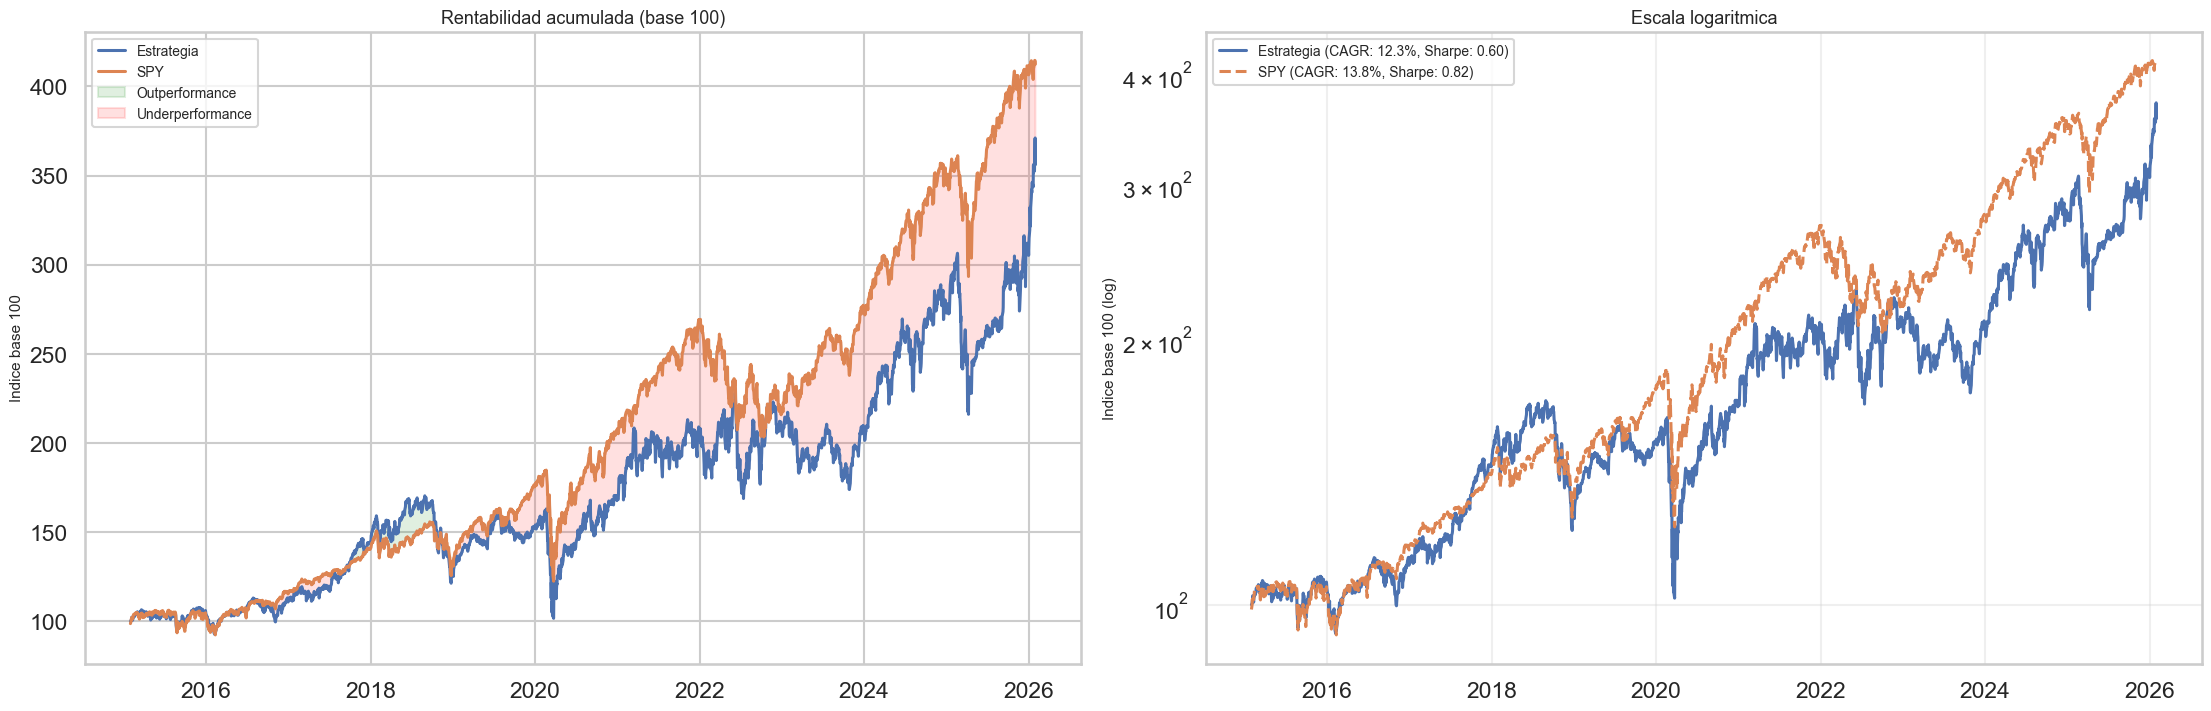

In [5]:
# Variables coherentes con el resto del notebook (tomadas de `metrics`)
def _as_ratio(x):
    x = float(x)
    return x / 100.0 if abs(x) > 2 else x  # por si metrics se guardo en % en lugar de ratio

cagr_s = _as_ratio(metrics.loc[metrics["metric"] == "CAGR", "strategy"].iloc[0])
cagr_b = _as_ratio(metrics.loc[metrics["metric"] == "CAGR", "spy"].iloc[0])
sharpe_s = float(metrics.loc[metrics["metric"] == "Sharpe", "strategy"].iloc[0])
sharpe_b = float(metrics.loc[metrics["metric"] == "Sharpe", "spy"].iloc[0])

cum = (1 + returns_daily[["strategy", "spy"]]).cumprod() * 100
spread = cum["strategy"] - cum["spy"]

fig, axes = plt.subplots(1, 2, figsize=(22, 7), constrained_layout=True)

# Panel 1: escala lineal con sombreado
axes[0].plot(cum.index, cum["strategy"], label="Estrategia", linewidth=2.2)
axes[0].plot(cum.index, cum["spy"], label="SPY", linewidth=2.2)
axes[0].fill_between(cum.index, cum["strategy"], cum["spy"],
                     where=(spread >= 0).to_numpy(), color="green", alpha=0.12, label="Outperformance")
axes[0].fill_between(cum.index, cum["strategy"], cum["spy"],
                     where=(spread < 0).to_numpy(), color="red", alpha=0.12, label="Underperformance")
axes[0].set_title("Rentabilidad acumulada (base 100)")
axes[0].set_ylabel("Indice base 100")
axes[0].legend(loc="upper left", fontsize=10)

# Panel 2: escala logaritmica con metricas en leyenda
axes[1].plot(cum.index, cum["strategy"],
             label=f"Estrategia (CAGR: {cagr_s:.1%}, Sharpe: {sharpe_s:.2f})", linewidth=2.2)
axes[1].plot(cum.index, cum["spy"],
             label=f"SPY (CAGR: {cagr_b:.1%}, Sharpe: {sharpe_b:.2f})", linewidth=2.2, linestyle="--")
axes[1].set_yscale("log")
axes[1].set_title("Escala logaritmica")
axes[1].set_ylabel("Indice base 100 (log)")
axes[1].legend(loc="upper left", fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.show()


---

## 5. Distribuciones de retornos

El histograma mensual compara el perfil de dispersiones entre estrategia y SPY: colas mas gruesas indican meses con movimientos extremos mas frecuentes. El heatmap anual-mensual permite identificar visualmente si la estrategia tiene patrones estacionales o concentra su rendimiento en periodos especificos.

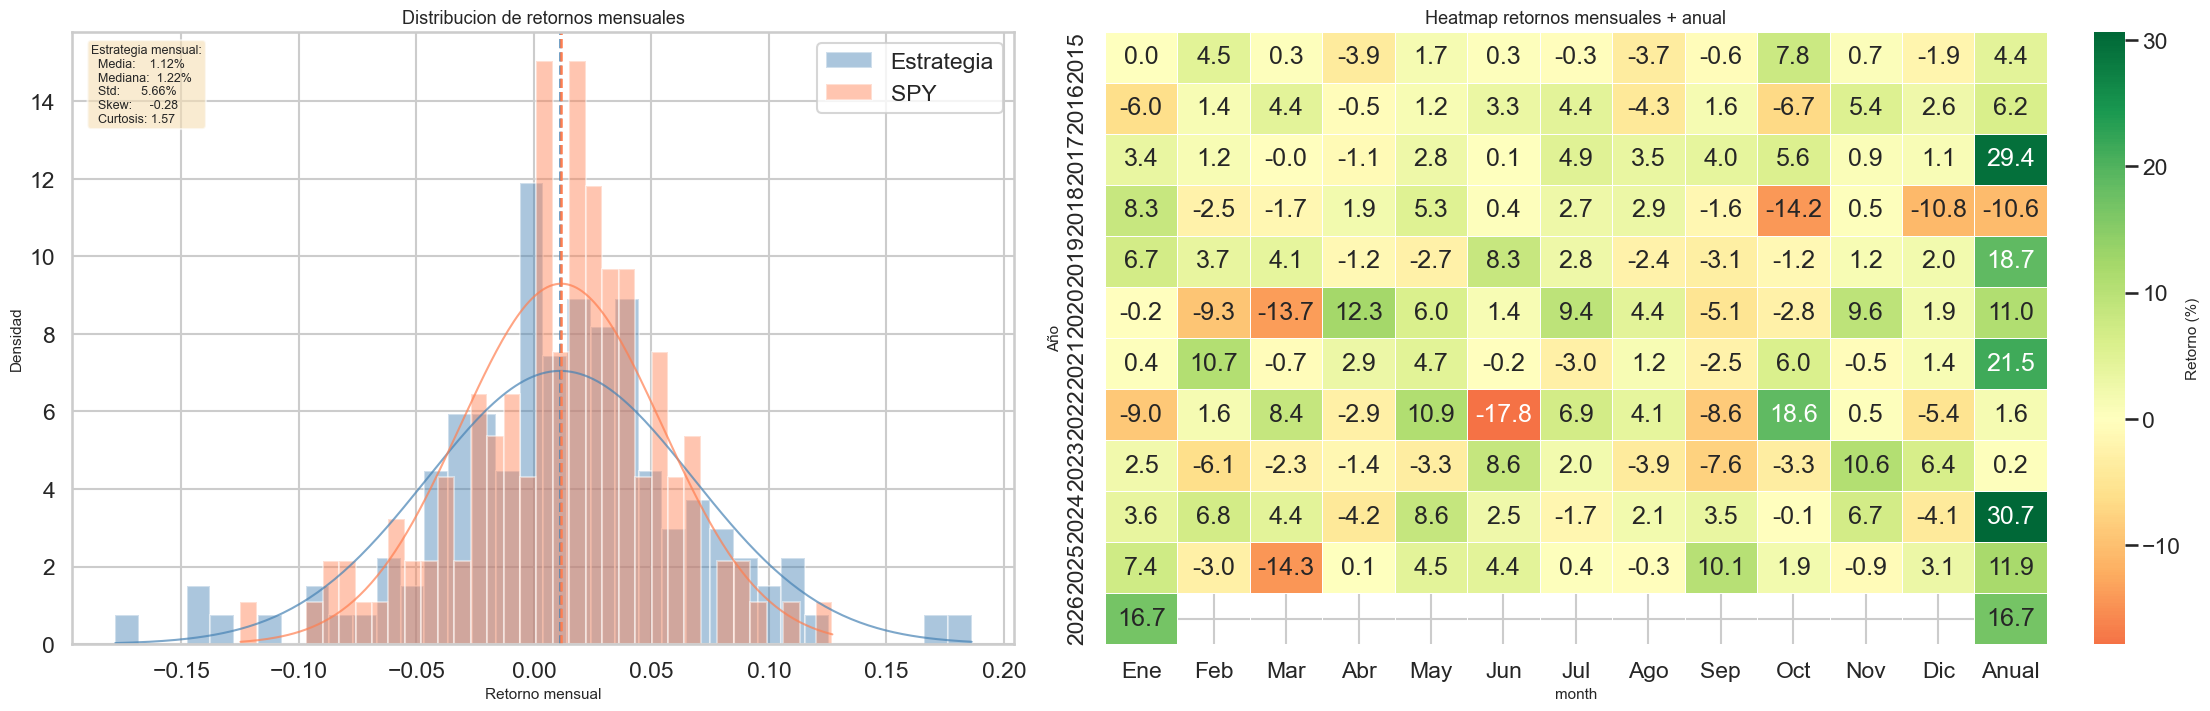

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(22, 7), constrained_layout=True)

# Panel 1: histograma mensual con curva normal
for col, color, label in [("strategy", "steelblue", "Estrategia"), ("spy", "coral", "SPY")]:
    ret = monthly_returns[col].dropna()
    axes[0].hist(ret, bins=36, density=True, alpha=0.45, color=color, edgecolor="white", label=label)
    axes[0].axvline(ret.mean(), color=color, linestyle="--", linewidth=1.8)
    # Curva normal superpuesta
    x = np.linspace(ret.min(), ret.max(), 200)
    axes[0].plot(x, stats.norm.pdf(x, ret.mean(), ret.std()), color=color, linewidth=1.5, alpha=0.7)

# Textbox de stats
s_ret = monthly_returns["strategy"].dropna()
box_text = (f"Estrategia mensual:\n"
            f"  Media:    {s_ret.mean():.2%}\n"
            f"  Mediana:  {s_ret.median():.2%}\n"
            f"  Std:      {s_ret.std():.2%}\n"
            f"  Skew:     {s_ret.skew():.2f}\n"
            f"  Curtosis: {s_ret.kurtosis():.2f}")
axes[0].text(0.02, 0.98, box_text, transform=axes[0].transAxes, fontsize=9,
             va="top", bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.6))
axes[0].set_title("Distribucion de retornos mensuales")
axes[0].set_xlabel("Retorno mensual")
axes[0].set_ylabel("Densidad")
axes[0].legend()

# Panel 2: heatmap con columna anual
heat = monthly_returns["strategy"].copy() * 100
heat_df = pd.DataFrame({"year": heat.index.year, "month": heat.index.month, "value": heat.values})
heat_pivot = heat_df.pivot(index="year", columns="month", values="value").reindex(columns=range(1, 13))

# Columna anual
annual_by_year = annual_returns["strategy"].copy() * 100
for yr in heat_pivot.index:
    mask = annual_by_year.index.year == yr
    heat_pivot.loc[yr, "Anual"] = float(annual_by_year[mask].values[0]) if mask.any() else np.nan

months = ["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep", "Oct", "Nov", "Dic", "Anual"]
sns.heatmap(heat_pivot, cmap="RdYlGn", center=0, annot=True, fmt=".1f",
            linewidths=0.4, cbar_kws={"label": "Retorno (%)"}, ax=axes[1])
axes[1].set_title("Heatmap retornos mensuales + anual")
axes[1].set_xticklabels(months, rotation=0)
axes[1].set_ylabel("Año")
plt.show()

---

## 6. Scatter anual y trimestral

Los scatter plots comparan retornos periodicos de la estrategia frente al SPY. La linea de regresion captura la sensibilidad (beta), el $R^2$ mide la proporcion de varianza explicada por el benchmark, y la linea de 45 grados indica retorno identico. Puntos por encima de la diagonal representan periodos de outperformance. Se incluyen ambas granularidades porque el scatter anual puede engañar con pocas observaciones; el trimestral aporta mas datos pero con mayor ruido.

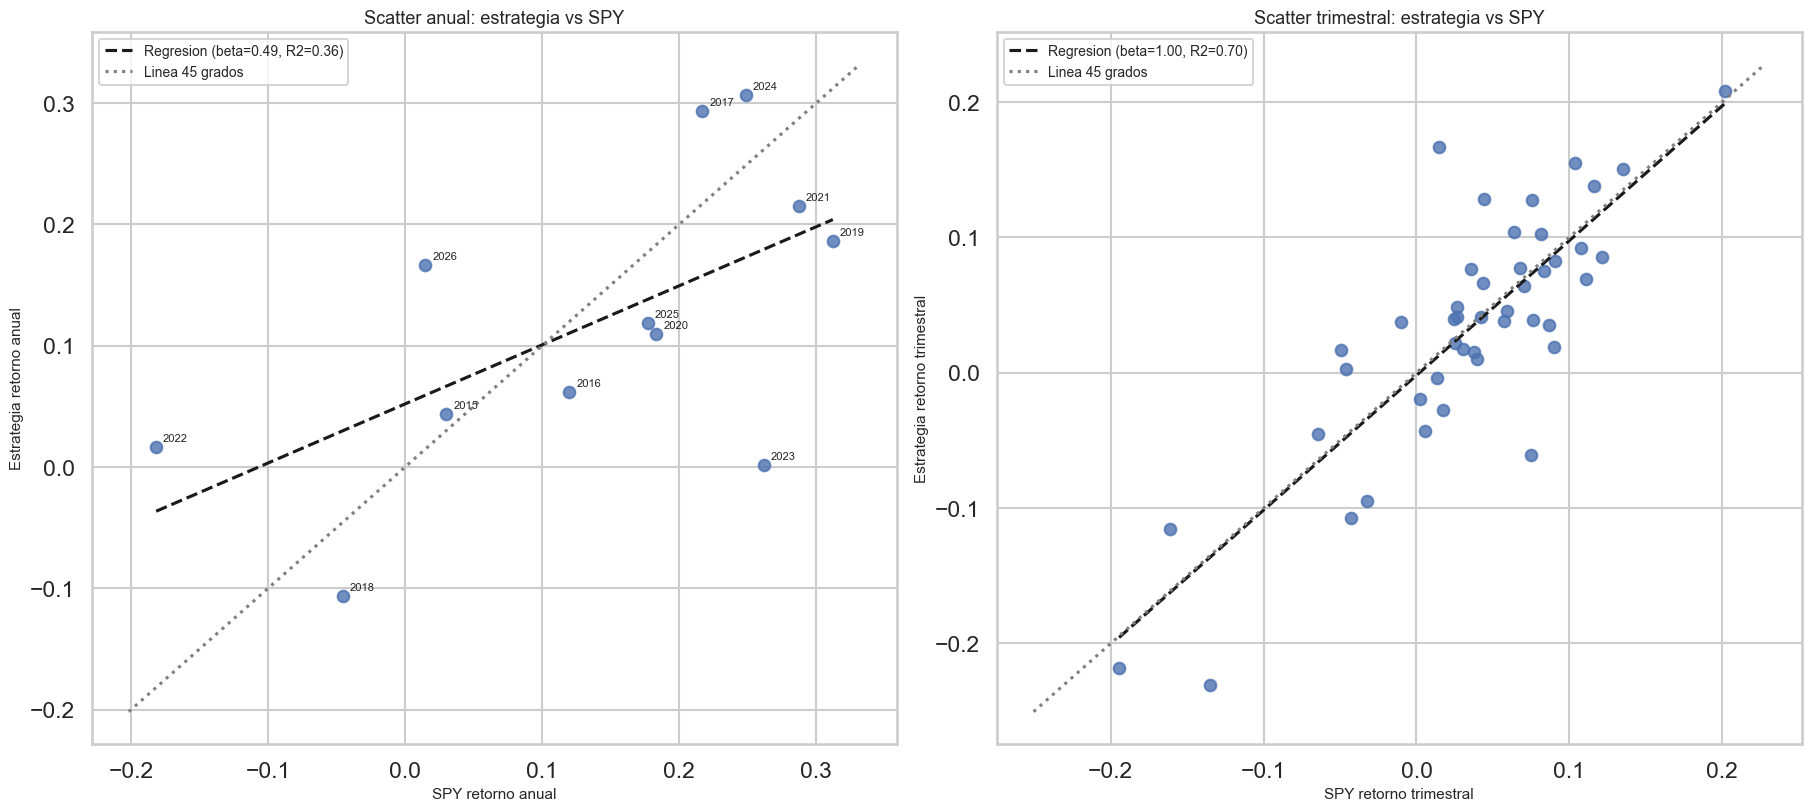

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8), constrained_layout=True)

for ax, ret_df, freq in [
    (axes[0], annual_returns.dropna(), "anual"),
    (axes[1], quarterly_returns.dropna(), "trimestral"),
]:
    x = ret_df["spy"].to_numpy()
    y = ret_df["strategy"].to_numpy()
    reg = stats.linregress(x, y)
    r2 = reg.rvalue ** 2

    ax.scatter(x, y, s=70, alpha=0.8)
    xs = np.sort(x)
    ax.plot(xs, reg.intercept + reg.slope * xs, "k--",
            label=f"Regresion (beta={reg.slope:.2f}, R2={r2:.2f})")
    lims = [min(x.min(), y.min()) - 0.02, max(x.max(), y.max()) + 0.02]
    ax.plot(lims, lims, ":", color="gray", label="Linea 45 grados")
    ax.set_title(f"Scatter {freq}: estrategia vs SPY")
    ax.set_xlabel(f"SPY retorno {freq}")
    ax.set_ylabel(f"Estrategia retorno {freq}")
    ax.legend(fontsize=10)

    if freq == "anual":
        ret_df = ret_df.copy()
        ret_df["year"] = ret_df.index.year
        for _, row in ret_df.iterrows():
            ax.annotate(str(int(row["year"])), (row["spy"], row["strategy"]),
                        textcoords="offset points", xytext=(5, 4), fontsize=8)

plt.show()

---

## 7. Persistencia de regimenes

La matriz de transicion mide la probabilidad de que un mes positivo sea seguido por otro positivo (o negativo), y viceversa. Si la probabilidad en la diagonal es alta, existe inercia de regimen. La distribucion de rachas complementa esta vision mostrando cuantos meses consecutivos se mantiene el signo: rachas largas positivas sugieren momentum sostenido, rachas negativas largas indican periodos de estres prolongado.

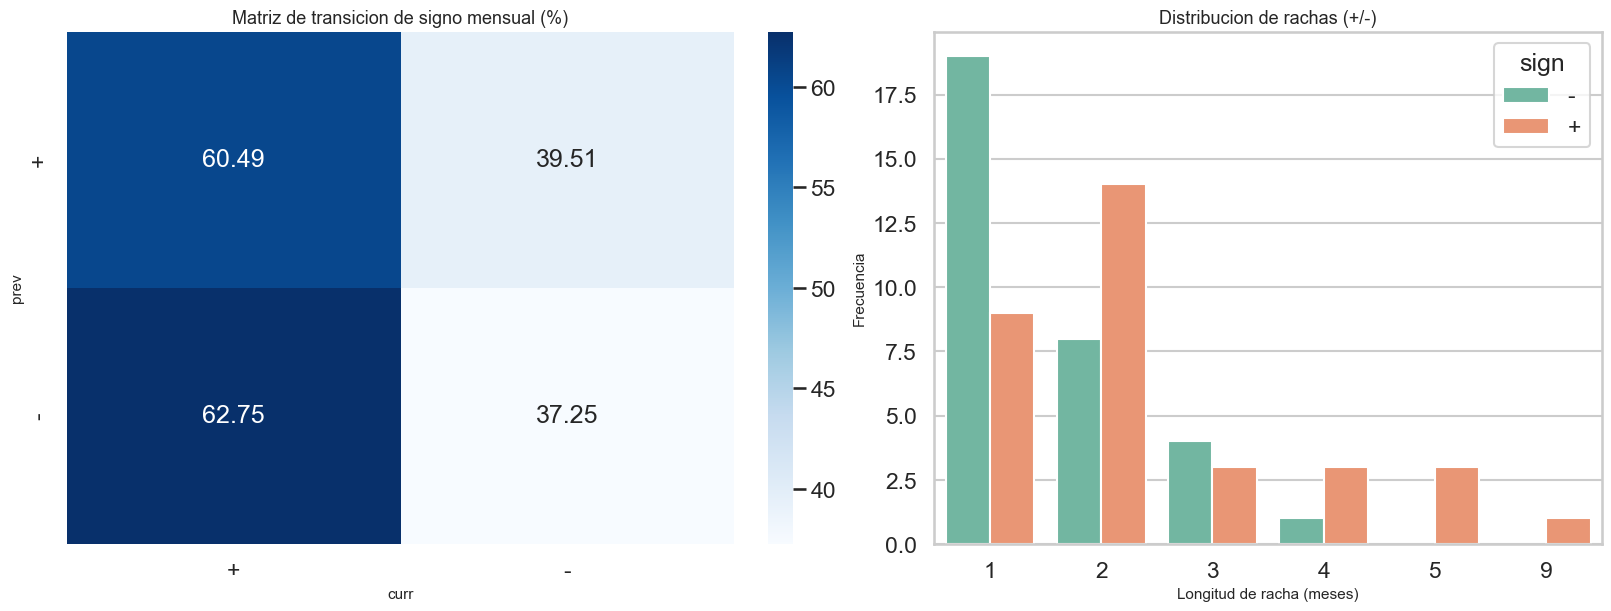

In [8]:
monthly_sign = np.where(monthly_returns["strategy"] >= 0, "+", "-")
trans_df = pd.DataFrame({"prev": pd.Series(monthly_sign).shift(1), "curr": monthly_sign}).dropna()
transition = pd.crosstab(trans_df["prev"], trans_df["curr"], normalize="index") * 100

sign_series = pd.Series(monthly_sign, index=monthly_returns.index)
groups = (sign_series != sign_series.shift(1)).cumsum()
streak_df = pd.DataFrame({
    "sign": sign_series.groupby(groups).first().values,
    "length": sign_series.groupby(groups).size().values,
})

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
sns.heatmap(transition, annot=True, fmt=".2f", cmap="Blues", ax=axes[0])
axes[0].set_title("Matriz de transicion de signo mensual (%)")

sns.countplot(data=streak_df, x="length", hue="sign", ax=axes[1], palette="Set2")
axes[1].set_title("Distribucion de rachas (+/-)")
axes[1].set_xlabel("Longitud de racha (meses)")
axes[1].set_ylabel("Frecuencia")
plt.show()

---

## 8. Riesgo dinamico

Tres paneles complementarios muestran la evolucion temporal del riesgo. El **drawdown** compara la profundidad de las caidas entre estrategia y SPY: un drawdown mas pronunciado implica mayor riesgo de ruina percibida. El **rolling Sharpe** (ventana de 126 dias, ~6 meses) muestra si la eficiencia riesgo-retorno es estable o ciclica. El **rolling beta** mide como varia la exposicion al mercado en el tiempo: un beta que oscila mucho sugiere que la estrategia cambia de caracter en distintos regimenes.

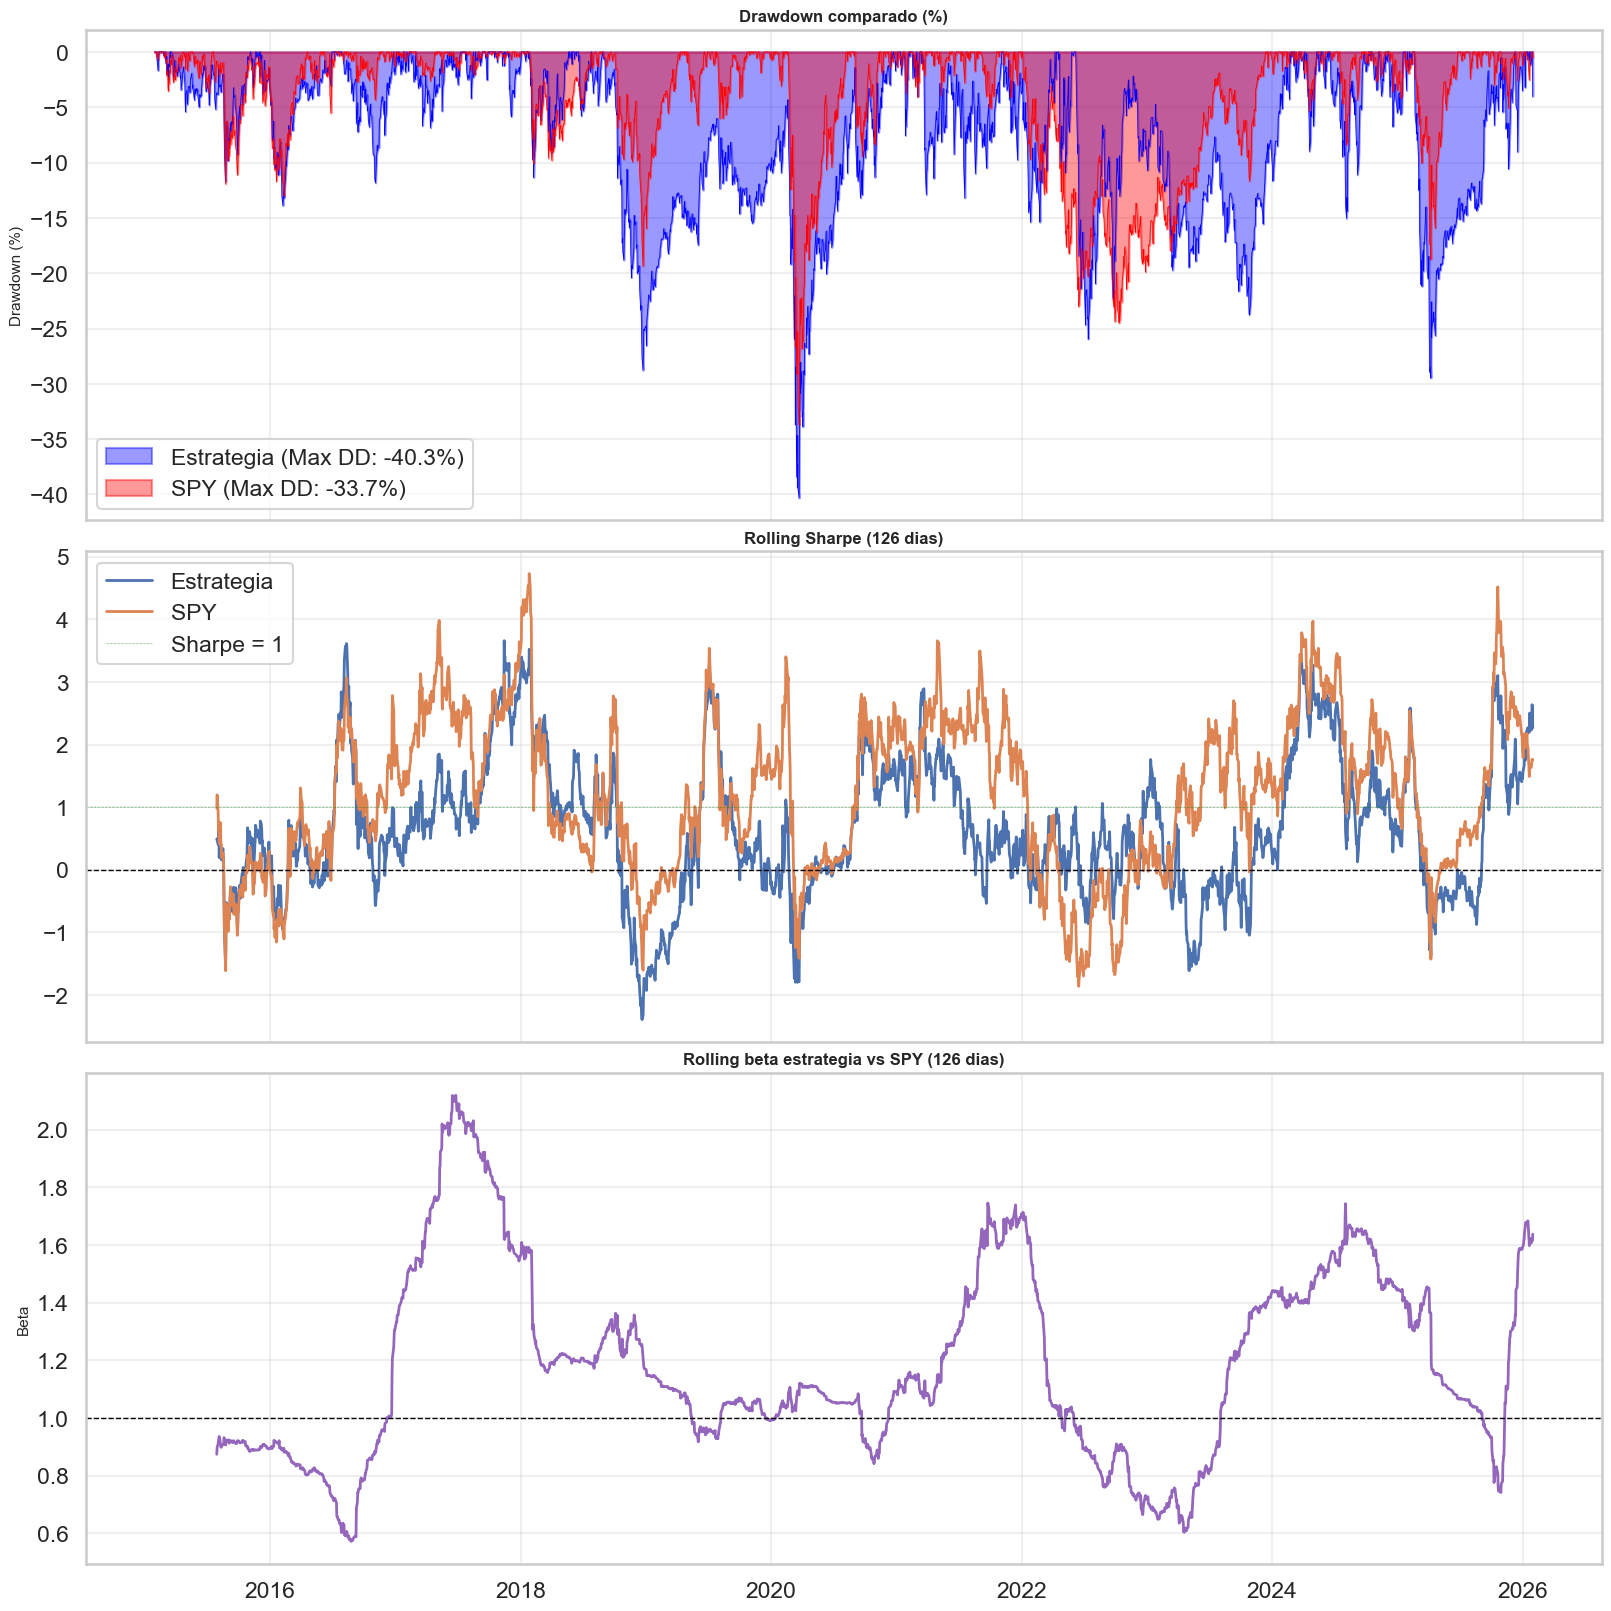

In [9]:
# Variables coherentes con el resto del notebook (tomadas de `metrics`)
def _as_ratio(x):
    x = float(x)
    return x / 100.0 if abs(x) > 2 else x  # por si metrics se guardo en % en lugar de ratio

mdd_s = _as_ratio(metrics.loc[metrics["metric"] == "Max Drawdown", "strategy"].iloc[0])
mdd_b = _as_ratio(metrics.loc[metrics["metric"] == "Max Drawdown", "spy"].iloc[0])

wealth = (1 + returns_daily[["strategy", "spy"]]).cumprod()
dd = wealth / wealth.cummax() - 1

win = 126
roll_mu = returns_daily[["strategy", "spy"]].rolling(win).mean()
roll_std = returns_daily[["strategy", "spy"]].rolling(win).std(ddof=1)
roll_sharpe = np.sqrt(TRADING_DAYS) * ((roll_mu - RF_DAILY) / roll_std)

roll_beta = (
    returns_daily["strategy"].rolling(win).cov(returns_daily["spy"])
    / returns_daily["spy"].rolling(win).var()
)

fig, axes = plt.subplots(3, 1, figsize=(16, 16), sharex=True, constrained_layout=True)

# Drawdown con fill_between
axes[0].fill_between(dd.index, dd["strategy"] * 100, 0, alpha=0.4, color="blue",
                     label=f"Estrategia (Max DD: {mdd_s:.1%})")
axes[0].fill_between(dd.index, dd["spy"] * 100, 0, alpha=0.4, color="red",
                     label=f"SPY (Max DD: {mdd_b:.1%})")
axes[0].plot(dd.index, dd["strategy"] * 100, color="blue", linewidth=0.5)
axes[0].plot(dd.index, dd["spy"] * 100, color="red", linewidth=0.5)
axes[0].set_title("Drawdown comparado (%)", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Drawdown (%)")
axes[0].legend(loc="lower left")
axes[0].grid(True, alpha=0.3)

axes[1].plot(roll_sharpe.index, roll_sharpe["strategy"], label="Estrategia", linewidth=2)
axes[1].plot(roll_sharpe.index, roll_sharpe["spy"], label="SPY", linewidth=2)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].axhline(1, color="green", linestyle="--", linewidth=0.5, alpha=0.5, label="Sharpe = 1")
axes[1].set_title("Rolling Sharpe (126 dias)", fontsize=12, fontweight="bold")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(roll_beta.index, roll_beta, color="tab:purple", linewidth=2)
axes[2].axhline(1, color="black", linestyle="--", linewidth=1)
axes[2].set_title("Rolling beta estrategia vs SPY (126 dias)", fontsize=12, fontweight="bold")
axes[2].set_ylabel("Beta")
axes[2].grid(True, alpha=0.3)

plt.show()


---

## 9. Diagnostico operativo y Analisis de comisiones

Este bloque traduce las fricciones de ejecucion a impacto economico medible. Se analizan tres tipos de eventos: ordenes rechazadas por falta de cash (`no_fill_cash`), salidas forzosas con precio proxy (cuando un activo deja de cotizar), y la comparacion entre la politica de reweight y la baseline sin reweight. Adicionalmente se desglosan las comisiones por tipo de orden para evaluar si el coste es marginal o estructural en la explicacion del resultado final.

Las comisiones se analizan en terminos absolutos y relativos para evaluar su peso en el resultado. El ratio fee/capital inicial mide el coste total como proporcion de la inversion original, mientras que fee/equity final lo contextualiza contra el patrimonio acumulado. Se identifica tambien el impacto del minimo por orden: ordenes pequenas que pagan mas comision de la que corresponderia por su notional generan un sobrecoste que puede ser significativo en estrategias con muchos rebalanceos.

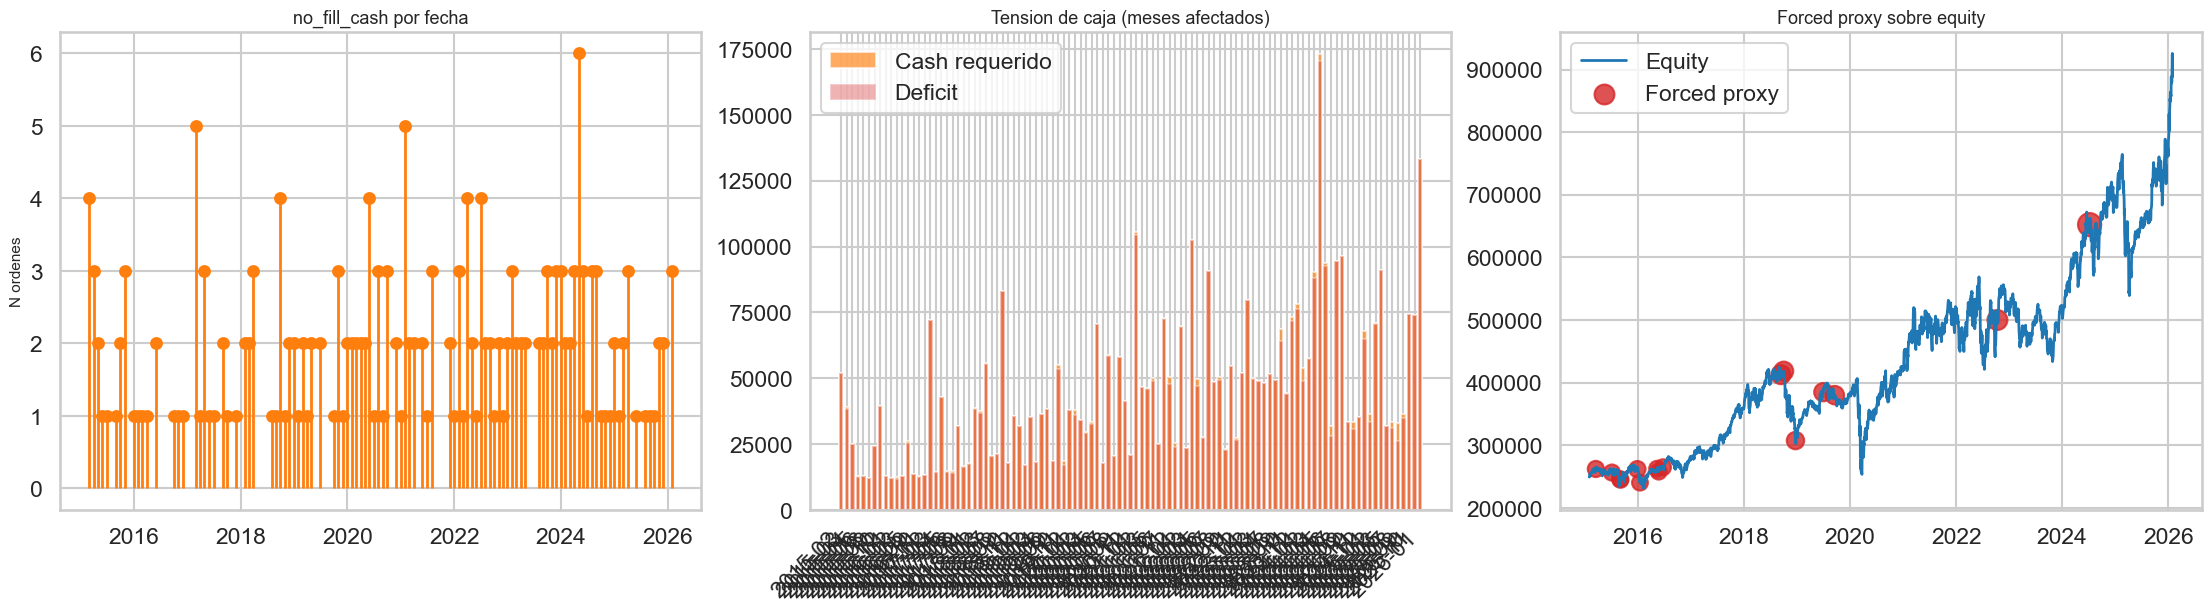

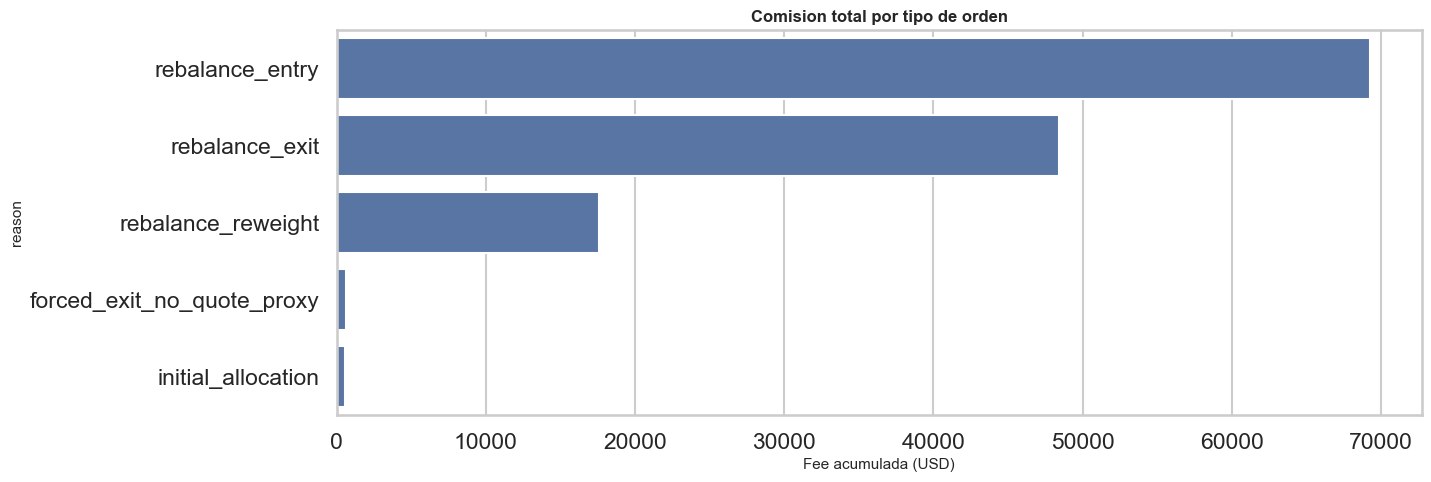

Comisiones totales:      $136,439.95
  Fee / Capital inicial:  54.58%
  Fee / Equity final:     15.36%
  Compras:               $69,837.08
  Ventas:                $66,602.87
  Ordenes con minimo:     1635, sobrecoste: $32,671.43
  no_fill_cash:           209 ordenes en 105 fechas
  forced proxy:           16 exits, fee $621.78
  Politica sin reweight:  equity $1,223,675.25, fee $112,581.11


In [10]:
# --- Excepciones ---
no_fill_cash_df = orders.loc[
    orders["status"] == "no_fill_cash",
    ["date", "symbol", "reason", "price", "cash_after", "policy_mode"],
].copy().sort_values(["date", "symbol"])
no_fill_by_date = no_fill_cash_df.groupby("date").size().rename("count")

forced_proxy_df = orders.loc[
    (orders["reason"] == "forced_exit_no_quote_proxy") & (orders["status"] == "filled"),
    ["date", "symbol", "price", "fee", "proxy_price_date", "policy_mode"],
].copy().sort_values(["date", "symbol"])

reb = rebalance_summary.copy().sort_values("date")
if "n_rebalance_entry_no_fill_cash" not in reb.columns:
    reb["n_rebalance_entry_no_fill_cash"] = 0
reb["required_cash_proxy"] = reb["equity"] * 0.05 * reb["n_rebalance_entry_no_fill_cash"]
reb["deficit_proxy"] = np.clip(reb["required_cash_proxy"] - reb["cash"], 0, None)
reb_tension = reb.loc[reb["n_rebalance_entry_no_fill_cash"] > 0].copy()

# --- Visuals ---
fig, axes = plt.subplots(1, 3, figsize=(22, 6), constrained_layout=True)

if len(no_fill_by_date) > 0:
    axes[0].vlines(no_fill_by_date.index, 0, no_fill_by_date.values, color="tab:orange", linewidth=2)
    axes[0].scatter(no_fill_by_date.index, no_fill_by_date.values, color="tab:orange", s=60)
axes[0].set_title("no_fill_cash por fecha")
axes[0].set_ylabel("N ordenes")

if len(reb_tension) > 0:
    x = np.arange(len(reb_tension))
    labels = reb_tension["date"].dt.strftime("%Y-%m")
    axes[1].bar(x, reb_tension["required_cash_proxy"], color="tab:orange", alpha=0.65, label="Cash requerido")
    axes[1].bar(x, reb_tension["deficit_proxy"], color="tab:red", alpha=0.35, label="Deficit")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels, rotation=45, ha="right")
    axes[1].legend(loc="upper left")
axes[1].set_title("Tension de caja (meses afectados)")

axes[2].plot(portfolio_daily["date"], portfolio_daily["equity"], color="tab:blue", linewidth=2, label="Equity")
if len(forced_proxy_df) > 0:
    fp = forced_proxy_df.groupby("date", as_index=False)["fee"].sum()
    eq_map = portfolio_daily.set_index("date")["equity"]
    yvals = fp["date"].map(eq_map)
    sizes = 40 + (fp["fee"] / fp["fee"].max() * 240)
    axes[2].scatter(fp["date"], yvals, color="tab:red", s=sizes, alpha=0.8, label="Forced proxy")
axes[2].set_title("Forced proxy sobre equity")
axes[2].legend(loc="upper left")
plt.show()

# --- Comisiones ---
filled = orders.loc[(orders["status"] == "filled") & (orders["notional"].abs() > 0)].copy()
filled["min_fee_hit"] = (filled["notional"].abs() * fee_rate) < fee_min
filled["extra_min"] = np.where(filled["min_fee_hit"], fee_min - filled["notional"].abs() * fee_rate, 0.0)

total_fee = float(cost_summary["total_fee"].iloc[0])
init_cap = float(cost_summary["initial_capital"].iloc[0])
final_eq = float(cost_summary["final_equity"].iloc[0])

# Policy comparison
policy_check = n4_checks.loc[n4_checks["check"] == "policy_reweight_tradeoff_documented", "details"]
fail_if(len(policy_check) == 0, "No existe check de politica en n4_checks")
txt = policy_check.iloc[0]
m_fee = re.search(r"delta_fee=([-+]?\d*\.?\d+)", txt)
m_eq = re.search(r"delta_final_equity=([-+]?\d*\.?\d+)", txt)
fail_if(m_fee is None or m_eq is None, f"No se parsean deltas: {txt}")
delta_fee = float(m_fee.group(1))
delta_eq = float(m_eq.group(1))

# Fee by reason chart
fee_reason = filled.groupby("reason", as_index=False)["fee"].sum().sort_values("fee", ascending=False)
fig, ax = plt.subplots(figsize=(14, 5))
sns.barplot(data=fee_reason, x="fee", y="reason", orient="h", ax=ax)
ax.set_title("Comision total por tipo de orden", fontsize=12, fontweight="bold")
ax.set_xlabel("Fee acumulada (USD)")
plt.show()

print(f"Comisiones totales:      ${total_fee:,.2f}")
print(f"  Fee / Capital inicial:  {100 * total_fee / init_cap:.2f}%")
print(f"  Fee / Equity final:     {100 * total_fee / final_eq:.2f}%")
print(f"  Compras:               ${cost_summary['buy_fee'].iloc[0]:,.2f}")
print(f"  Ventas:                ${cost_summary['sell_fee'].iloc[0]:,.2f}")
print(f"  Ordenes con minimo:     {int(filled['min_fee_hit'].sum())}, sobrecoste: ${filled['extra_min'].sum():,.2f}")
print(f"  no_fill_cash:           {len(no_fill_cash_df)} ordenes en {no_fill_cash_df['date'].nunique()} fechas")
print(f"  forced proxy:           {len(forced_proxy_df)} exits, fee ${forced_proxy_df['fee'].sum():,.2f}")
print(f"  Politica sin reweight:  equity ${final_eq - delta_eq:,.2f}, fee ${total_fee - delta_fee:,.2f}")

---

## 10. Monte Carlo directo (25M carteras)

El test de robustez principal del enunciado: se simulan 25 millones de carteras aleatorias de 20 activos, muestreadas sin reemplazo cada mes del universo elegible, con un coste mensual del 0.46%. Cada cartera acumula riqueza sobre los retornos forward reales observados, lo que hace la prueba **no parametrica** (no asume distribucion teorica).

La metrica clave es el **percentil** de la estrategia real dentro de la distribucion de monos: un percentil alto (>95) indica que la estrategia produce resultados que serian muy improbables por azar. Se reporta tambien `P(monkey > estrategia)` como la probabilidad de que un mono aleatorio supere a la estrategia. El requisito de ejecucion es menor a 24 horas.

Para evitar desalineacion temporal, el universo mensual del Monte Carlo incluye tambien la fecha de asignacion inicial (enero 2015), de forma que estrategia y monos comparen exactamente el mismo tramo temporal.

In [11]:
strategy_final_equity = float(cost_summary["final_equity"].iloc[0])
initial_capital = float(cost_summary["initial_capital"].iloc[0])
strategy_return_vs_initial_capital = float(cost_summary["return_vs_initial_capital"].iloc[0])
strategy_return_from_first_valuation = float(cost_summary["return_from_first_valuation"].iloc[0])

# ================================================================
# 11A. Preparacion del universo mensual para Monte Carlo directo
# ================================================================
sig_mc = signals_input[["rebalance_date", "symbol", "eligible_for_signals", "close_rebalance"]].copy()
sig_mc["rebalance_date"] = pd.to_datetime(sig_mc["rebalance_date"])
sig_mc = sig_mc.sort_values(["symbol", "rebalance_date"]).reset_index(drop=True)

# Retorno forward mensual por simbolo (t -> t+1)
sig_mc["close_next"] = sig_mc.groupby("symbol", observed=True)["close_rebalance"].shift(-1)
sig_mc["fwd_ret"] = sig_mc["close_next"] / sig_mc["close_rebalance"] - 1

# Fechas realmente operadas en N4 + fecha inicial para alinear horizonte.
initial_mc_rows = portfolio_daily.loc[portfolio_daily["is_initial_allocation"] == True, "date"]
fail_if(len(initial_mc_rows) == 0, "No se encontro fecha inicial en portfolio_daily")
initial_mc_date = pd.Timestamp(initial_mc_rows.drop_duplicates().sort_values().iloc[0])

signal_months = pd.Index(
    pd.concat(
        [pd.Series([initial_mc_date]), rebalance_summary["date"]],
        ignore_index=True,
    )
    .drop_duplicates()
    .sort_values()
)

mc_universe = sig_mc.loc[
    sig_mc["rebalance_date"].isin(signal_months)
    & (sig_mc["eligible_for_signals"] == True)
    & np.isfinite(sig_mc["fwd_ret"])
    & (sig_mc["fwd_ret"] > -0.999),
    ["rebalance_date", "symbol", "fwd_ret"],
].copy()

month_groups = []
month_meta_rows = []
for dt, grp in mc_universe.groupby("rebalance_date", observed=True):
    arr = grp["fwd_ret"].to_numpy(dtype=np.float32)
    if len(arr) >= MONKEY_K:
        month_groups.append((pd.Timestamp(dt), arr))
        month_meta_rows.append(
            {
                "rebalance_date": pd.Timestamp(dt),
                "n_assets": int(len(arr)),
                "mean_fwd_ret": float(arr.mean()),
                "std_fwd_ret": float(arr.std(ddof=1)) if len(arr) > 1 else np.nan,
            }
        )

fail_if(len(month_groups) == 0, "No hay meses validos para Monte Carlo")

month_meta_df = pd.DataFrame(month_meta_rows).sort_values("rebalance_date").reset_index(drop=True)

print("Universo Monte Carlo preparado")
print(f"  Meses validos:           {len(month_groups)}")
print(
    f"  Activos/mes min-med-max: {int(month_meta_df['n_assets'].min())}-"
    f"{int(month_meta_df['n_assets'].median())}-"
    f"{int(month_meta_df['n_assets'].max())}"
)
print(f"  Monos declarados:        {N_MONKEYS:,}")
print(f"  Lotes por mes:           {int(np.ceil(N_MONKEYS / MONKEY_BATCH))}")
print(f"  Return vs capital (N4):  {strategy_return_vs_initial_capital:.2%}")
print(
    f"  Ventana MC (meses t):     "
    f"{month_meta_df['rebalance_date'].min().date()} -> "
    f"{month_meta_df['rebalance_date'].max().date()}"
)

display(month_meta_df.head(8))


Universo Monte Carlo preparado
  Meses validos:           132
  Activos/mes min-med-max: 460-478-484
  Monos declarados:        25,000,000
  Lotes por mes:           100
  Return vs capital (N4):  255.41%
  Ventana MC (meses t):     2015-01-30 -> 2025-12-31


,rebalance_date,n_assets,mean_fwd_ret,std_fwd_ret
0,2015-01-30,480,0.057724,0.070270
1,2015-02-27,478,-0.009861,0.051630
2,2015-03-31,478,0.005234,0.068347
3,2015-04-30,478,0.008115,0.058337
4,2015-05-29,478,-0.022066,0.051085
5,2015-06-30,473,0.009423,0.081211
6,2015-07-31,473,-0.054042,0.058168
7,2015-08-31,475,-0.032359,0.070574


In [12]:
# ================================================================
# 11B. Ejecucion Monte Carlo directo (no parametrico) por lotes
# ================================================================    
cache_ready = (
    pd.io.common.file_exists(MC_DIRECT_WEALTH_NPY)
    and pd.io.common.file_exists(MC_DIRECT_SUMMARY_CSV)
)

if (not FORCE_RECOMPUTE_MONKEYS) and cache_ready:
    monkey_wealth = np.load(MC_DIRECT_WEALTH_NPY).astype(np.float32, copy=False)
    direct_cache = pd.read_csv(MC_DIRECT_SUMMARY_CSV)

    direct_elapsed = (
        float(direct_cache["runtime_sec"].iloc[0])
        if "runtime_sec" in direct_cache.columns
        else np.nan
    )
    mc_start = (
        pd.to_datetime(
            direct_cache["mc_start_utc"].iloc[0],
            utc=True,
            errors="coerce",
        )
        if "mc_start_utc" in direct_cache.columns
        else pd.NaT
    )
    mc_end = (
        pd.to_datetime(
            direct_cache["mc_end_utc"].iloc[0],
            utc=True,
            errors="coerce",
        )
        if "mc_end_utc" in direct_cache.columns
        else pd.NaT
    )

    rng = np.random.default_rng(MONKEY_SEED)
    print(f"Monte Carlo directo cargado desde cache: {MC_DIRECT_WEALTH_NPY}")

else:
    rng = np.random.default_rng(MONKEY_SEED)
    log_growth = np.zeros(N_MONKEYS, dtype=np.float32)

    mc_start = pd.Timestamp.now(tz="UTC")
    t0 = time.perf_counter()

    for m_idx, (month_dt, month_ret) in enumerate(month_groups, start=1):
        n_assets = month_ret.size
        start = 0

        while start < N_MONKEYS:
            batch = min(MONKEY_BATCH, N_MONKEYS - start)

            # Seleccion aleatoria de K activos sin reemplazo por mono
            idx = sample_no_replace(rng, batch, n_assets, MONKEY_K)

            # Retorno mensual de cada mono (media equiponderada de K activos)
            sampled = month_ret[idx].mean(axis=1, dtype=np.float32) - MONKEY_COST
            sampled = np.clip(sampled, -0.95, None)

            # Acumulacion en log-wealth para estabilidad numerica
            log_growth[start:start + batch] += np.log1p(sampled).astype(np.float32)
            start += batch

        if m_idx == 1 or m_idx % 12 == 0 or m_idx == len(month_groups):
            elapsed = time.perf_counter() - t0
            eta = ((elapsed / m_idx) * (len(month_groups) - m_idx)) / 60
            print(f"  Mes {m_idx:03d}/{len(month_groups)} | {month_dt.date()} | "
                  f"{elapsed/60:.1f} min | ETA {eta:.1f} min")

    direct_elapsed = time.perf_counter() - t0
    mc_end = pd.Timestamp.now(tz="UTC")

    # Equity final de cada mono
    monkey_wealth = (initial_capital * np.exp(log_growth.astype(np.float64))).astype(np.float32)
    np.save(MC_DIRECT_WEALTH_NPY, monkey_wealth)

    print(f"\nMonte Carlo directo recalculado en {direct_elapsed/60:.1f} minutos.")
    print(f"Cache guardada en: {MC_DIRECT_WEALTH_NPY}")

  Mes 001/132 | 2015-01-30 | 0.5 min | ETA 69.2 min


  Mes 012/132 | 2015-12-31 | 6.3 min | ETA 63.3 min


  Mes 024/132 | 2016-12-30 | 12.7 min | ETA 57.4 min


  Mes 036/132 | 2017-12-29 | 19.1 min | ETA 51.0 min


  Mes 048/132 | 2018-12-31 | 25.6 min | ETA 44.7 min


...

  Mes 084/132 | 2021-12-31 | 44.5 min | ETA 25.4 min


  Mes 096/132 | 2022-12-30 | 50.7 min | ETA 19.0 min


  Mes 108/132 | 2023-12-29 | 57.0 min | ETA 12.7 min


  Mes 120/132 | 2024-12-31 | 63.2 min | ETA 6.3 min


  Mes 132/132 | 2025-12-31 | 69.5 min | ETA 0.0 min

Monte Carlo directo recalculado en 69.5 minutos.
Cache guardada en: data/processed/n5_mc_direct_wealth.npy


,n_monkeys,seed,runtime_sec,runtime_min,runtime_lt_24h,mc_start_utc,mc_end_utc,strategy_final_equity,strategy_return_vs_initial_capital,strategy_return_from_first_valuation,strategy_percentile,p_monkey_beats_strategy,p05,p50,p95,ci95_low,ci95_high
0,25000000,42,4170.219786,69.503663,True,2026-02-27 15:53:07.662541+00:00,2026-02-27 17:02:37.882357+00:00,888522.88015,2.554092,2.562145,99.985924,0.000141,321309.09375,438206.3125,600193.0,302798.185937,637981.5


,q01,q05,q10,q25,q50,q75,q90,q95,q99
0,282680.28125,321309.09375,344005.375,385715.9375,438206.3125,498159.40625,559579.375,600193.0,685282.6875


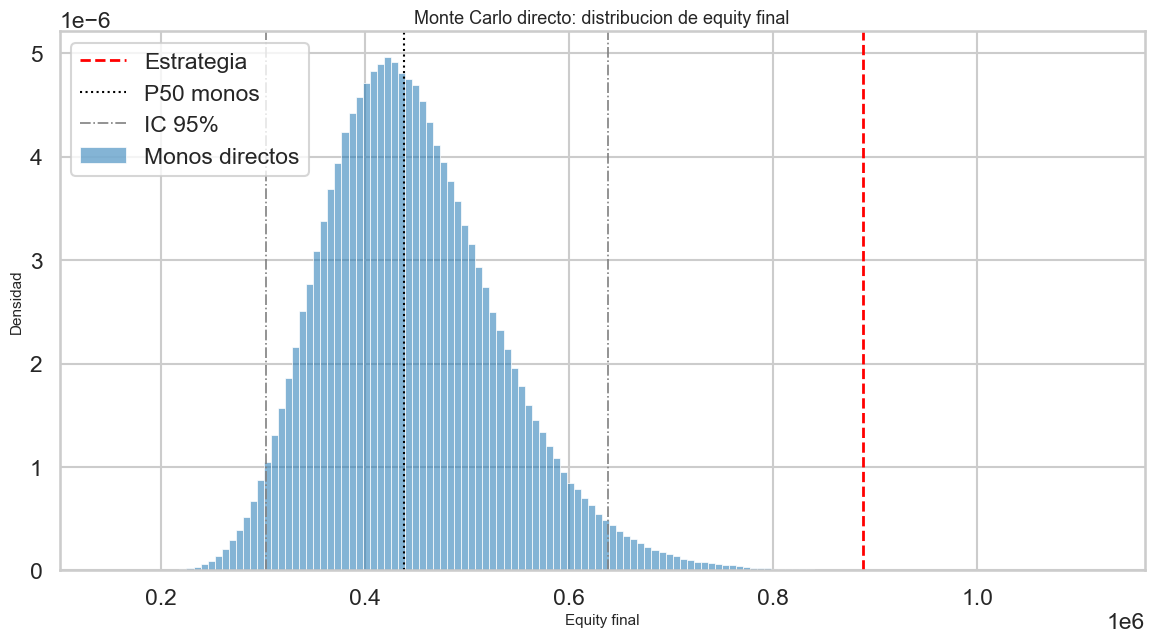

CSV directo guardados:
  data/processed/n5_mc_direct_summary.csv
  data/processed/n5_mc_direct_quantiles.csv
  data/processed/n5_mc_direct_sample.csv
Requisito <24h: PASS


In [13]:
# ================================================================
# 11C. Resultados del Monte Carlo directo (bloque principal)
# ================================================================
p_strat = float((monkey_wealth <= strategy_final_equity).mean() * 100)
p_monkey_beats = float((monkey_wealth > strategy_final_equity).mean())

p05, p50, p95 = np.percentile(monkey_wealth, [5, 50, 95])
ci_low, ci_high = np.percentile(monkey_wealth, [2.5, 97.5])

direct_summary_df = pd.DataFrame([{
    "n_monkeys": int(N_MONKEYS),
    "seed": int(MONKEY_SEED),
    "runtime_sec": float(direct_elapsed) if np.isfinite(direct_elapsed) else np.nan,
    "runtime_min": float(direct_elapsed / 60) if np.isfinite(direct_elapsed) else np.nan,
    "runtime_lt_24h": bool(np.isfinite(direct_elapsed) and direct_elapsed < 24 * 3600),
    "mc_start_utc": str(mc_start) if pd.notna(mc_start) else "",
    "mc_end_utc": str(mc_end) if pd.notna(mc_end) else "",
    "strategy_final_equity": float(strategy_final_equity),
    "strategy_return_vs_initial_capital": float(strategy_return_vs_initial_capital),
    "strategy_return_from_first_valuation": float(strategy_return_from_first_valuation),
    "strategy_percentile": float(p_strat),
    "p_monkey_beats_strategy": float(p_monkey_beats),
    "p05": float(p05),
    "p50": float(p50),
    "p95": float(p95),
    "ci95_low": float(ci_low),
    "ci95_high": float(ci_high),
}])

direct_quant_df = pd.DataFrame([{
    "q01": float(np.percentile(monkey_wealth, 1)),
    "q05": float(p05),
    "q10": float(np.percentile(monkey_wealth, 10)),
    "q25": float(np.percentile(monkey_wealth, 25)),
    "q50": float(p50),
    "q75": float(np.percentile(monkey_wealth, 75)),
    "q90": float(np.percentile(monkey_wealth, 90)),
    "q95": float(p95),
    "q99": float(np.percentile(monkey_wealth, 99)),
}])

plot_n = min(MONKEY_PLOT_N, len(monkey_wealth))
plot_sample = monkey_wealth[rng.integers(0, len(monkey_wealth), size=plot_n)]
direct_sample_df = pd.DataFrame({"equity_final": plot_sample})

# Export CSV (directo)
direct_summary_df.to_csv(MC_DIRECT_SUMMARY_CSV, index=False)
direct_quant_df.to_csv(MC_DIRECT_QUANT_CSV, index=False)
direct_sample_df.to_csv(MC_DIRECT_SAMPLE_CSV, index=False)

display(direct_summary_df)
display(direct_quant_df)

plt.figure(figsize=(14, 7))
sns.histplot(plot_sample, bins=140, stat="density", color="tab:blue", alpha=0.55, label="Monos directos")
plt.axvline(strategy_final_equity, color="red", linestyle="--", linewidth=2, label="Estrategia")
plt.axvline(p50, color="black", linestyle=":", linewidth=1.5, label="P50 monos")
plt.axvline(ci_low, color="gray", linestyle="-.", linewidth=1.2, label="IC 95%")
plt.axvline(ci_high, color="gray", linestyle="-.", linewidth=1.2)
plt.title("Monte Carlo directo: distribucion de equity final")
plt.xlabel("Equity final")
plt.ylabel("Densidad")
plt.legend(loc="upper left")
plt.show()

print(f"CSV directo guardados:")
print(f"  {MC_DIRECT_SUMMARY_CSV}")
print(f"  {MC_DIRECT_QUANT_CSV}")
print(f"  {MC_DIRECT_SAMPLE_CSV}")
print(f"Requisito <24h: {'PASS' if np.isfinite(direct_elapsed) and direct_elapsed < 24*3600 else 'FAIL'}")


---

## 12. Sensibilidad parametrica

Como control cruzado, se compara la distribucion del Monte Carlo directo con una aproximacion parametrica (normal con FPC). Si ambas distribuciones son similares, la aproximacion valida el metodo directo. Si difieren significativamente, indicaria que la distribucion empirica tiene propiedades (colas gruesas, asimetria) que la normal no captura.

Sensibilidad recalculada y guardada


,mode,n,mean,std,p5,p25,p50,p75,p95
0,directo,1000000,446631.78125,85882.296875,321356.459375,385788.085938,438234.109375,498213.359375,600332.590625
1,parametrico,1000000,446632.87500,86012.664062,320306.000000,385618.757812,438647.328125,498868.976562,600232.403125


,quantile,directo,parametrico,delta_param_menos_directo,delta_rel_pct
0,5.0,321356.459375,320306.000000,-1050.459375,-0.326883
1,25.0,385788.085938,385618.757812,-169.328125,-0.043891
2,50.0,438234.109375,438647.328125,413.218750,0.094292
3,75.0,498213.359375,498868.976562,655.617188,0.131594
4,95.0,600332.590625,600232.403125,-100.187500,-0.016689


,compare_n,ks_stat,ks_pvalue
0,1000000,0.002636,0.001917


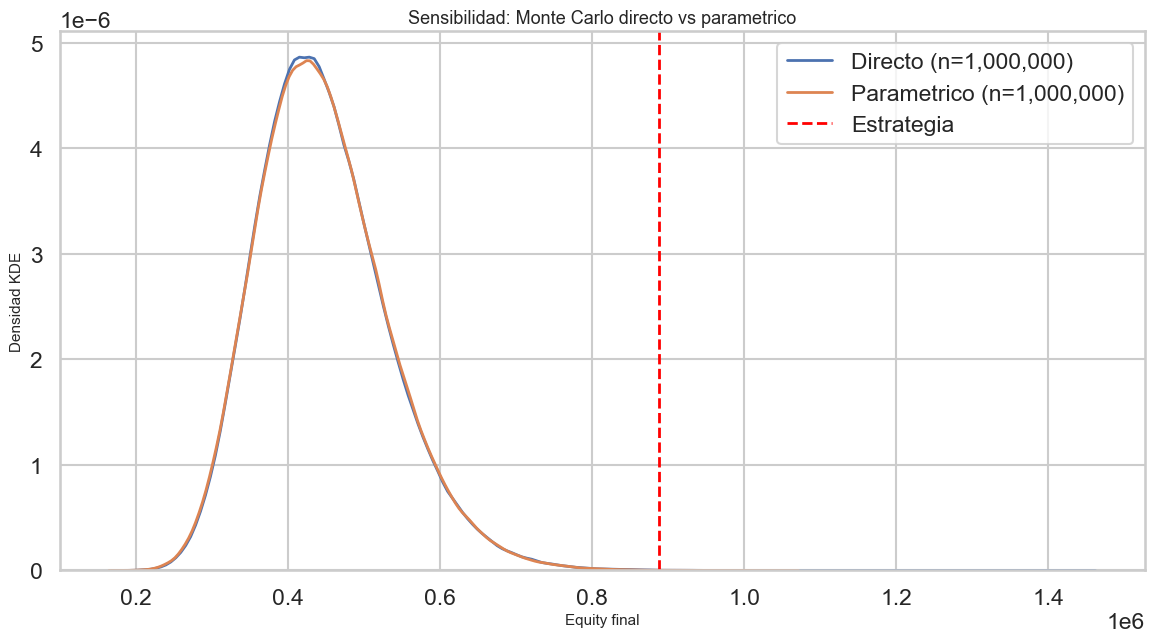

CSV sensibilidad guardados:
  data/processed/n5_mc_sens_summary.csv
  data/processed/n5_mc_sens_quantiles.csv
  data/processed/n5_mc_sens_tests.csv
  data/processed/n5_mc_sens_samples.csv


In [14]:
# ================================================================
# 12. Sensibilidad parametrica (control de modelo, no resultado principal)
# ================================================================
sens_cache_ready = (
    pd.io.common.file_exists(MC_SENS_SUMMARY_CSV)
    and pd.io.common.file_exists(MC_SENS_QUANT_CSV)
    and pd.io.common.file_exists(MC_SENS_TESTS_CSV)
    and pd.io.common.file_exists(MC_SENS_SAMPLES_CSV)
)

if (not FORCE_RECOMPUTE_MONKEYS) and sens_cache_ready:
    sens_summary_df = pd.read_csv(MC_SENS_SUMMARY_CSV)
    sens_quantiles_df = pd.read_csv(MC_SENS_QUANT_CSV)
    sens_tests_df = pd.read_csv(MC_SENS_TESTS_CSV)
    sens_samples_df = pd.read_csv(MC_SENS_SAMPLES_CSV)

    direct_sub = sens_samples_df.loc[sens_samples_df["mode"] == "directo", "equity_final"].to_numpy(dtype=np.float32)
    param_sub = sens_samples_df.loc[sens_samples_df["mode"] == "parametrico", "equity_final"].to_numpy(dtype=np.float32)

    print(f"Sensibilidad cargada desde cache")
else:
    param_n = min(N_MONKEYS_PARAM, N_MONKEYS)
    rng_p = np.random.default_rng(MONKEY_SEED + 7)

    mu_list, std_list = [], []
    for _, arr in month_groups:
        mu = float(np.mean(arr) - MONKEY_COST)
        sigma = float(np.std(arr, ddof=1))
        n_a = len(arr)
        fpc = np.sqrt(max((n_a - MONKEY_K) / (n_a - 1), 0.0)) if n_a > 1 else 0.0
        mu_list.append(mu)
        std_list.append(sigma / np.sqrt(MONKEY_K) * fpc)

    mu_arr = np.array(mu_list, dtype=np.float32)
    std_arr = np.array(std_list, dtype=np.float32)

    log_growth_p = np.zeros(param_n, dtype=np.float32)
    for m in range(len(mu_arr)):
        draws = rng_p.normal(loc=float(mu_arr[m]), scale=float(std_arr[m]), size=param_n).astype(np.float32)
        draws = np.clip(draws, -0.95, None)
        log_growth_p += np.log1p(draws).astype(np.float32)

    monkey_param = (initial_capital * np.exp(log_growth_p.astype(np.float64))).astype(np.float32)

    compare_n = min(1_000_000, len(monkey_wealth), len(monkey_param))
    direct_sub = monkey_wealth[rng_p.integers(0, len(monkey_wealth), size=compare_n)]
    param_sub = monkey_param[rng_p.integers(0, len(monkey_param), size=compare_n)]

    ks_stat, ks_pvalue = stats.ks_2samp(direct_sub, param_sub)

    def _stats(arr, mode):
        q = np.percentile(arr, [5, 25, 50, 75, 95])
        return {
            "mode": mode,
            "n": int(len(arr)),
            "mean": float(np.mean(arr)),
            "std": float(np.std(arr, ddof=1)),
            "p5": float(q[0]),
            "p25": float(q[1]),
            "p50": float(q[2]),
            "p75": float(q[3]),
            "p95": float(q[4]),
        }

    sens_summary_df = pd.DataFrame([_stats(direct_sub, "directo"), _stats(param_sub, "parametrico")])

    quantiles = np.array([5, 25, 50, 75, 95], dtype=float)
    q_direct = np.percentile(direct_sub, quantiles)
    q_param = np.percentile(param_sub, quantiles)

    sens_quantiles_df = pd.DataFrame({
        "quantile": quantiles,
        "directo": q_direct,
        "parametrico": q_param,
    })
    sens_quantiles_df["delta_param_menos_directo"] = sens_quantiles_df["parametrico"] - sens_quantiles_df["directo"]
    sens_quantiles_df["delta_rel_pct"] = (
        100
        * sens_quantiles_df["delta_param_menos_directo"]
        / sens_quantiles_df["directo"]
    )

    sens_tests_df = pd.DataFrame([{
        "compare_n": int(compare_n),
        "ks_stat": float(ks_stat),
        "ks_pvalue": float(ks_pvalue),
    }])

    sens_samples_df = pd.DataFrame({
        "equity_final": np.concatenate([direct_sub, param_sub]),
        "mode": np.repeat(["directo", "parametrico"], repeats=[len(direct_sub), len(param_sub)]),
    })

    # Export CSV (sensibilidad)
    sens_summary_df.to_csv(MC_SENS_SUMMARY_CSV, index=False)
    sens_quantiles_df.to_csv(MC_SENS_QUANT_CSV, index=False)
    sens_tests_df.to_csv(MC_SENS_TESTS_CSV, index=False)
    sens_samples_df.to_csv(MC_SENS_SAMPLES_CSV, index=False)

    print("Sensibilidad recalculada y guardada")

display(sens_summary_df)
display(sens_quantiles_df)
display(sens_tests_df)

plt.figure(figsize=(14, 7))
sns.kdeplot(direct_sub, label=f"Directo (n={len(direct_sub):,})", linewidth=2)
sns.kdeplot(param_sub, label=f"Parametrico (n={len(param_sub):,})", linewidth=2)
plt.axvline(strategy_final_equity, color="red", linestyle="--", linewidth=2, label="Estrategia")
plt.title("Sensibilidad: Monte Carlo directo vs parametrico")
plt.xlabel("Equity final")
plt.ylabel("Densidad KDE")
plt.legend()
plt.show()

print("CSV sensibilidad guardados:")
print(f"  {MC_SENS_SUMMARY_CSV}")
print(f"  {MC_SENS_QUANT_CSV}")
print(f"  {MC_SENS_TESTS_CSV}")
print(f"  {MC_SENS_SAMPLES_CSV}")

---

## 13. Cierre analitico

El resumen final consolida toda la evidencia producida por N5 en un unico cuadro que permite evaluar si la estrategia supera los cinco riesgos del enunciado: supervivencia (drawdown contenido), look-ahead (pipeline PIT verificado en N2), overfitting (percentil Monte Carlo alto), realismo de rebalanceo (diagnostico de excepciones), e impacto de costes (ratio fee/equity).

In [15]:
# ================================================================
# Normalizacion de nombres para esta celda (compatibles con N5)
# ================================================================
cagr_s = float(metrics.loc[metrics["metric"] == "CAGR", "strategy"].iloc[0])
cagr_b = float(metrics.loc[metrics["metric"] == "CAGR", "spy"].iloc[0])
sharpe_s = float(metrics.loc[metrics["metric"] == "Sharpe", "strategy"].iloc[0])
sharpe_b = float(metrics.loc[metrics["metric"] == "Sharpe", "spy"].iloc[0])
sortino_s = float(metrics.loc[metrics["metric"] == "Sortino", "strategy"].iloc[0])
sortino_b = float(metrics.loc[metrics["metric"] == "Sortino", "spy"].iloc[0])
vol_s = float(metrics.loc[metrics["metric"] == "Volatility (annualized)", "strategy"].iloc[0])
vol_b = float(metrics.loc[metrics["metric"] == "Volatility (annualized)", "spy"].iloc[0])
mdd_s = float(metrics.loc[metrics["metric"] == "Max Drawdown", "strategy"].iloc[0])
mdd_b = float(metrics.loc[metrics["metric"] == "Max Drawdown", "spy"].iloc[0])
bt = float(metrics.loc[metrics["metric"] == "Beta (vs SPY)", "strategy"].iloc[0])
al = float(metrics.loc[metrics["metric"] == "Alpha Jensen (annualized)", "strategy"].iloc[0])

total_ret_s = float((1 + returns_daily["strategy"]).prod() - 1)
total_ret_b = float((1 + returns_daily["spy"]).prod() - 1)
n_years = float(len(returns_daily) / TRADING_DAYS)

median_month_s = float(monthly_returns["strategy"].median())
median_month_b = float(monthly_returns["spy"].median())
pct_pos_months_s = float((monthly_returns["strategy"] > 0).mean())
pct_pos_months_b = float((monthly_returns["spy"] > 0).mean())

total_fee = float(cost_summary["total_fee"].iloc[0])
init_cap = float(cost_summary["initial_capital"].iloc[0])
final_eq = float(cost_summary["final_equity"].iloc[0])
ret_vs_initial_n4 = float(cost_summary["return_vs_initial_capital"].iloc[0])
ret_from_first_n4 = float(cost_summary["return_from_first_valuation"].iloc[0])

filled = orders.loc[(orders["status"] == "filled") & (orders["notional"].abs() > 0)].copy()
filled["fee_prop"] = filled["notional"].abs() * fee_rate
filled["min_fee_hit"] = filled["fee_prop"] < fee_min
filled["extra_min"] = np.where(filled["min_fee_hit"], fee_min - filled["fee_prop"], 0.0)

if "no_fill_cash_df" not in globals():
    no_fill_cash_df = orders.loc[orders["status"] == "no_fill_cash"].copy()

# Deltas de politica with/without reweight
if "delta_fee" not in globals() or "delta_eq" not in globals():
    policy_check = n4_checks.loc[n4_checks["check"] == "policy_reweight_tradeoff_documented", "details"]
    if len(policy_check) > 0:
        txt = str(policy_check.iloc[0])
        m_fee = re.search(r"delta_fee=([-+]?\d*\.?\d+)", txt)
        m_eq = re.search(r"delta_final_equity=([-+]?\d*\.?\d+)", txt)
        delta_fee = float(m_fee.group(1)) if m_fee else 0.0
        delta_eq = float(m_eq.group(1)) if m_eq else 0.0
    else:
        delta_fee, delta_eq = 0.0, 0.0

# Monte Carlo (si no existen, se calculan/normalizan)
if "strategy_final_equity" not in globals():
    strategy_final_equity = final_eq

if "p50" not in globals() and "monkey_wealth" in globals():
    p50 = float(np.percentile(monkey_wealth, 50))
if "p_strat" not in globals() and "monkey_wealth" in globals():
    p_strat = float((monkey_wealth <= strategy_final_equity).mean() * 100)
if "p_monkey_beats" not in globals() and "monkey_wealth" in globals():
    p_monkey_beats = float((monkey_wealth > strategy_final_equity).mean())

if "p50" not in globals():
    p50 = np.nan
if "p_strat" not in globals():
    p_strat = np.nan
if "p_monkey_beats" not in globals():
    p_monkey_beats = np.nan


# Mensajes auxiliares para mantener legibilidad
risk_efficiency_msg = (
    "Esto significa que, ajustado por riesgo, el SPY ha sido mas eficiente: "
    if sharpe_s < sharpe_b
    else "Esto confirma que la estrategia genera retorno por unidad de riesgo competitivo: "
)
risk_efficiency_detail = (
    "el mayor CAGR de la estrategia NO compensa proporcionalmente el mayor riesgo asumido."
    if sharpe_s < sharpe_b
    else "el mayor CAGR compensa adecuadamente el riesgo adicional."
)
reweight_conclusion = (
    "El coste adicional del reweight NO se justifica por el retorno extra."
    if delta_eq < 0
    else (
        "El retorno extra justifica las comisiones adicionales."
        if delta_eq > delta_fee
        else "El retorno extra no compensa el exceso de comisiones."
    )
)
mc_confidence_msg = (
    "Con un percentil >99%, podemos afirmar con alta confianza que el resultado NO es atribuible al azar."
    if p_strat > 99
    else (
        "El percentil sugiere que la estrategia tiene valor, aunque no de forma abrumadora."
        if p_strat > 90
        else "El percentil no es suficientemente alto para descartar el azar con confianza."
    )
)

print("=" * 70)
print("  ANALISIS CRITICO - LECTURA PARA COMITE DE INVERSIONES")
print("=" * 70)

# ---- 1. RENTABILIDAD EN CONTEXTO ----
print(f"""
1. RENTABILIDAD EN CONTEXTO
───────────────────────────────────────────────────────────────────
La estrategia de momentum ha generado un retorno total del
{total_ret_s:.2%} durante {n_years:.1f} anos de backtest, lo que
equivale a un CAGR del {cagr_s:.2%}. El SPY ha retornado un
{total_ret_b:.2%} total (CAGR {cagr_b:.2%}) en la misma ventana.

Sin embargo, la rentabilidad mediana mensual de la estrategia es
del {median_month_s:.2%} frente al {median_month_b:.2%} del SPY,
lo que indica que la MEDIA esta siendo arrastrada por unos pocos
meses excepcionales. El porcentaje de meses positivos es del
{pct_pos_months_s:.1%} (SPY: {pct_pos_months_b:.1%}).

Conclusion parcial: la estrategia genera rentabilidad absoluta
{'superior' if cagr_s > cagr_b else 'comparable'} al benchmark,
pero hay que cruzar esta cifra con el riesgo asumido.
""")

# ---- 2. RIESGO: LAS CIFRAS QUE MATIZAN ----
print(f"""
2. RIESGO: LAS CIFRAS QUE MATIZAN
───────────────────────────────────────────────────────────────────
La volatilidad anualizada de la estrategia ({vol_s:.2%}) es
significativamente {'superior' if vol_s > vol_b else 'inferior'}
a la del SPY ({vol_b:.2%}), una ratio de {vol_s/vol_b:.2f}x.
El max drawdown de la estrategia ({mdd_s:.2%}) frente al del
SPY ({mdd_b:.2%}) confirma que la estrategia asume mas riesgo
de cola. Un inversor que hubiera entrado en el peor momento
habria visto caer su cartera un {abs(mdd_s):.0%} antes de
recuperarse, frente al {abs(mdd_b):.0%} del indice.

Conclusion parcial: la estrategia ofrece mayor rentabilidad a
cambio de asumir mayor volatilidad y drawdowns mas profundos.
La pregunta es si el mercado compensa adecuadamente ese riesgo
adicional.
""")

# ---- 3. EFICIENCIA RIESGO-RETORNO ----
print(f"""
3. EFICIENCIA RIESGO-RETORNO (LA PRUEBA DE FUEGO)
───────────────────────────────────────────────────────────────────
El Sharpe de la estrategia ({sharpe_s:.3f}) {'supera' if sharpe_s > sharpe_b else 'es inferior al'}
{'del' if sharpe_s <= sharpe_b else ''} SPY ({sharpe_b:.3f}). El Sortino, que
penaliza solo la volatilidad bajista, muestra un {sortino_s:.3f}
para la estrategia frente al {sortino_b:.3f} del benchmark.

{risk_efficiency_msg}
{risk_efficiency_detail}

Beta vs SPY: {bt:.3f}. La estrategia tiene una exposicion
{'superior' if bt > 1 else 'inferior'} al mercado, lo que explica
parte de su mayor volatilidad. Alpha de Jensen: {al:.4f}
({al:.2%} anualizado), que representa el exceso de retorno no
explicado por la exposicion al mercado.
""")

# ---- 4. IMPACTO DE COMISIONES ----
print(f"""
4. IMPACTO DE COMISIONES
───────────────────────────────────────────────────────────────────
Las comisiones totales ascienden a ${total_fee:,.2f}, un
{100*total_fee/init_cap:.1f}% del capital inicial y un
{100*total_fee/final_eq:.1f}% de la equity final. La comision
minima de $23 por orden ha afectado a {int(filled['min_fee_hit'].sum())}
ordenes, generando un sobrecoste de ${filled['extra_min'].sum():,.2f}
que no existiria con una estructura puramente proporcional.

La politica de reweight genera ${abs(delta_fee):,.0f} mas en
comisiones que la politica sin reweight, pero {'produce' if delta_eq > 0 else 'reduce la'}
equity {'superior' if delta_eq > 0 else 'final'} en ${abs(delta_eq):,.0f}.
{reweight_conclusion}
""")

# ---- 5. ROBUSTEZ ESTADISTICA (MONTE CARLO) ----
print(f"""
5. ROBUSTEZ ESTADISTICA (MONTE CARLO)
───────────────────────────────────────────────────────────────────
La estrategia se situa en el percentil {p_strat:.2f}% de la
distribucion de {N_MONKEYS:,} carteras aleatorias. Solo el
{p_monkey_beats:.4%} de los monos supera a la estrategia.

La mediana de los monos es ${p50:,.0f} frente a los ${strategy_final_equity:,.0f}
de la estrategia. Esto implica que la estrategia produce un
resultado {strategy_final_equity/p50:.1f}x superior al mono
mediano.

{mc_confidence_msg}
""")

# ---- 6. PREGUNTAS DEL ENUNCIADO ----
print(f"""
6. RESPUESTAS A LAS PREGUNTAS DEL ENUNCIADO
───────────────────────────────────────────────────────────────────
Sesgo de supervivencia: Mitigado parcialmente. El universo usa
la composicion historica del S&P 500 mes a mes (point-in-time),
pero los activos que desaparecen y sus precios historicos siguen
disponibles en el dataset. Una mitigacion completa requeriria
datos de delisting returns, que no estan disponibles.

Look-ahead: Eliminado. El pipeline garantiza que en cada fecha
de rebalanceo solo se usan datos conocidos hasta t-1. Los
retornos R6 y R12 excluyen el mes actual (lag de 1 mes), y las
senales se construyen con precios anteriores al dia de decision.

Overfitting: El test de Monte Carlo con 25M de monos demuestra
que el resultado de la estrategia no es replicable por azar
(percentil {p_strat:.1f}%). No se ha optimizado ningun parametro
sobre la muestra - los 20 activos, el z-score y los pesos
equiponderados son reglas fijas del enunciado, no resultado de
busqueda.

Rebalanceo irrealista: El motor ejecuta ventas al OPEN y compras
al CLOSE del mismo dia, con acciones enteras y comision con
minimo. Se registran {len(no_fill_cash_df)} ordenes no ejecutadas
por falta de cash, lo que demuestra que la simulacion respeta
restricciones reales.

Comisiones: Se han pagado ${total_fee:,.2f} en comisiones
({100*total_fee/init_cap:.1f}% del capital, {100*total_fee/final_eq:.1f}%
de la equity final). La comision minima de $23 ha impactado
{int(filled['min_fee_hit'].sum())} ordenes.
""")


  ANALISIS CRITICO - LECTURA PARA COMITE DE INVERSIONES

1. RENTABILIDAD EN CONTEXTO
───────────────────────────────────────────────────────────────────
La estrategia de momentum ha generado un retorno total del
256.21% durante 11.0 anos de backtest, lo que
equivale a un CAGR del 12.27%. El SPY ha retornado un
312.54% total (CAGR 13.78%) en la misma ventana.

Sin embargo, la rentabilidad mediana mensual de la estrategia es
del 1.22% frente al 1.70% del SPY,
lo que indica que la MEDIA esta siendo arrastrada por unos pocos
meses excepcionales. El porcentaje de meses positivos es del
60.9% (SPY: 69.9%).

Conclusion parcial: la estrategia genera rentabilidad absoluta
comparable al benchmark,
pero hay que cruzar esta cifra con el riesgo asumido.


2. RIESGO: LAS CIFRAS QUE MATIZAN
───────────────────────────────────────────────────────────────────
La volatilidad anualizada de la estrategia (24.18%) es
significativamente superior
a la del SPY (17.75%), una ratio de 1.36x.
El max drawdown de 

In [16]:
# Dictamen final formateado
outperforms_cagr = cagr_s > cagr_b
outperforms_sharpe = sharpe_s > sharpe_b
mc_robust = p_strat > 95

if outperforms_cagr and outperforms_sharpe and mc_robust:
    verdict = "FAVORABLE"
    detail = f"""La estrategia supera al benchmark tanto en terminos absolutos como \
ajustados por riesgo, y el resultado es estadisticamente robusto."""
elif outperforms_cagr and not outperforms_sharpe and mc_robust:
    verdict = "FAVORABLE CON MATICES"
    detail = f"""La estrategia genera mayor rentabilidad absoluta y es estadisticamente \
robusta, pero el mayor riesgo asumido hace que su eficiencia (Sharpe) \
sea inferior al benchmark.\nUn inversor debe aceptar mayor volatilidad \
y drawdowns mas profundos para capturar el exceso de retorno."""
elif not outperforms_cagr and mc_robust:
    verdict = "DESFAVORABLE (robusto pero insuficiente)"
    detail = "La estrategia no supera al benchmark en rentabilidad absoluta."
else:
    verdict = "NO CONCLUYENTE"
    detail = "El resultado no alcanza significancia estadistica suficiente."

print(f"""
Dictamen: {verdict}

{detail}

""")
print("=" * 70)


Dictamen: DESFAVORABLE (robusto pero insuficiente)

La estrategia no supera al benchmark en rentabilidad absoluta.




In [17]:
# Verificacion de completitud
cagr_s = metrics.loc[metrics["metric"] == "CAGR", "strategy"].iloc[0]
cagr_b = metrics.loc[metrics["metric"] == "CAGR", "spy"].iloc[0]
sharpe_s = metrics.loc[metrics["metric"] == "Sharpe", "strategy"].iloc[0]
maxdd_s = metrics.loc[metrics["metric"] == "Max Drawdown", "strategy"].iloc[0]

ret_vs_initial_n4 = float(cost_summary["return_vs_initial_capital"].iloc[0])
ret_from_first_n4 = float(cost_summary["return_from_first_valuation"].iloc[0])

required = {
    "CAGR",
    "Volatility (annualized)",
    "Sharpe",
    "Sortino",
    "Max Drawdown",
    "Beta (vs SPY)",
    "Alpha Jensen (annualized)",
}
present = set(metrics["metric"].tolist())
metrics_ok = required.issubset(present)
mc_ok = direct_elapsed < 24 * 3600 and N_MONKEYS >= 25_000_000

print("=" * 60)
print("  NOTEBOOK 5 — RESUMEN FINAL")
print("=" * 60)
print(f"  Ventana:              {returns_daily.index.min().date()} -> {returns_daily.index.max().date()}")
print(f"  CAGR estrategia:      {cagr_s:.4f} ({cagr_s:.2%})")
print(f"  CAGR SPY:             {cagr_b:.4f} ({cagr_b:.2%})")
print(f"  Sharpe estrategia:    {sharpe_s:.4f}")
print(f"  Max Drawdown:         {maxdd_s:.4f} ({maxdd_s:.2%})")
print(f"  Return vs capital:    {ret_vs_initial_n4:.2%}")
print(f"  Return desde val. 1:  {ret_from_first_n4:.2%}")
print(f"  Fee total:            ${total_fee:,.2f} ({100 * total_fee / final_eq:.1f}% equity final)")
print(f"  no_fill_cash:         {len(no_fill_cash_df)} ordenes")
print(f"  forced proxy exits:   {len(forced_proxy_df)} ordenes")
print("  ---")
print(f"  MC monos:             {N_MONKEYS:,}")
print(f"  MC tiempo:            {direct_elapsed/60:.1f} min (<24h: {'PASS' if mc_ok else 'FAIL'})")
print(f"  MC percentil:         {p_strat:.2f}%")
print(f"  MC P(monkey>strat):   {p_monkey_beats:.6f}")
print("  ---")
print(f"  Metricas completas:   {'PASS' if metrics_ok else 'FAIL'}")
print(f"  Monte Carlo valido:   {'PASS' if mc_ok else 'FAIL'}")
print("=" * 60)
if metrics_ok and mc_ok:
    print("  STATUS: PASS — Analisis completo. Pipeline defendible.")
else:
    print("  STATUS: FAIL — Revisar items marcados.")
print("=" * 60)


  NOTEBOOK 5 — RESUMEN FINAL
  Ventana:              2015-01-30 -> 2026-01-30
  CAGR estrategia:      0.1227 (12.27%)
  CAGR SPY:             0.1378 (13.78%)
  Sharpe estrategia:    0.6000
  Max Drawdown:         -0.4032 (-40.32%)
  Return vs capital:    255.41%
  Return desde val. 1:  256.21%
  Fee total:            $136,439.95 (15.4% equity final)
  no_fill_cash:         209 ordenes
  forced proxy exits:   16 ordenes
  ---
  MC monos:             25,000,000
  MC tiempo:            69.5 min (<24h: PASS)
  MC percentil:         99.99%
  MC P(monkey>strat):   0.000141
  ---
  Metricas completas:   PASS
  Monte Carlo valido:   PASS
  STATUS: PASS — Analisis completo. Pipeline defendible.
